# Merge

In [15]:
import scanpy as sc
import anndata

# 파일 경로
file1 = "/home/Data_Drive_8TB/kykim/2. CRC/CRC2/save_point/VisiumHD_GSM8594567_P1CRC.h5ad"
file2 = "/home/Data_Drive_8TB/kykim/2. CRC/CRC2/save_point/VisiumHD_GSM8594569_P5CRC.h5ad"
file3 = "/home/Data_Drive_8TB/kykim/2. CRC/CRC2/save_point/VisiumHD_GSM8594568_P2CRC.h5ad"

# AnnData 파일 로드
adata1 = sc.read_h5ad(file1)
adata2 = sc.read_h5ad(file2)
adata3 = sc.read_h5ad(file3)

# 각 샘플 이름을 sample 컬럼으로 추가
adata1.obs['sample'] = "VisiumHD_GSM8594567_P1CRC"
adata2.obs['sample'] = "VisiumHD_GSM8594569_P5CRC"
adata3.obs['sample'] = "VisiumHD_GSM8594568_P2CRC"

# 인덱스가 겹치지 않도록 prefix 추가
adata1.obs_names = ["P1CRC_" + str(i) for i in adata1.obs_names]
adata2.obs_names = ["P5CRC_" + str(i) for i in adata2.obs_names]
adata3.obs_names = ["P2CRC_" + str(i) for i in adata3.obs_names]

# concat으로 병합 (label 사용하지 않음)
adata_merged = anndata.concat(
    [adata1, adata2, adata3],
    join="outer",
    index_unique=None
)

# sample 컬럼이 문자열로 유지되도록 설정
adata_merged.obs['sample'] = adata_merged.obs['sample'].astype(str)


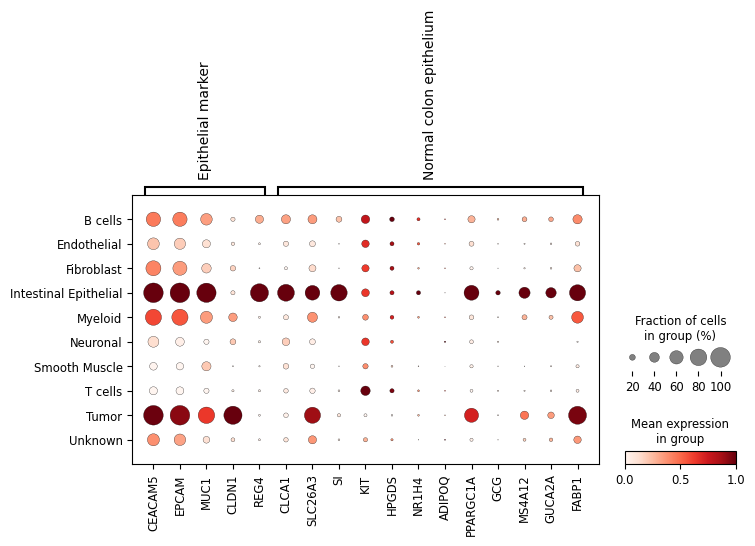

In [16]:
group_markers = {
    "Epithelial marker": [
        "CEACAM5", "EPCAM", "MUC1", "CLDN1", "REG4"
    ],
    "Normal colon epithelium": ["CLCA1", "SLC26A3", "SI", "KIT", "HPGDS", "NR1H4", "ADIPOQ", "PPARGC1A", "GCG", "MS4A12", "GUCA2A", "FABP1"]
}

existing_genes = {cat: [gene for gene in genes if gene in adata_merged.var_names] 
                  for cat, genes in group_markers.items()}

# 빈 리스트가 아닌 카테고리만 유지
existing_genes = {cat: genes for cat, genes in existing_genes.items() if genes}

sc.pl.dotplot(adata_merged, existing_genes, groupby="UnsupervisedL1", standard_scale="var")

Plotting for sample: VisiumHD_GSM8594567_P1CRC


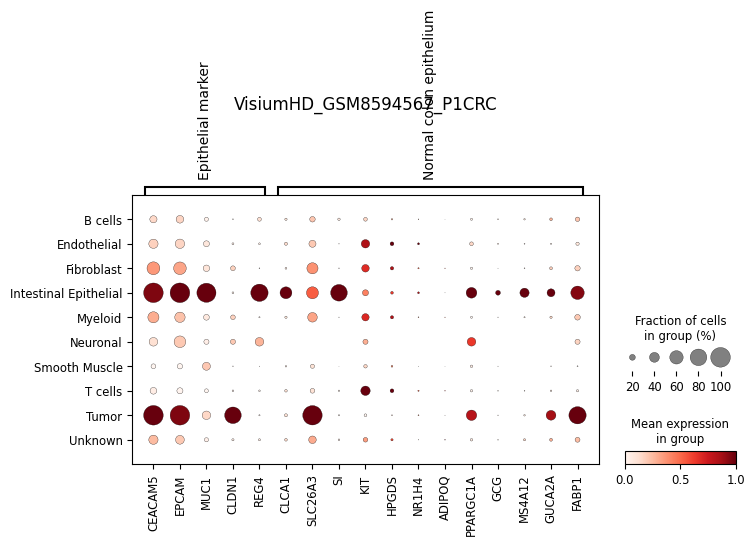

Plotting for sample: VisiumHD_GSM8594569_P5CRC


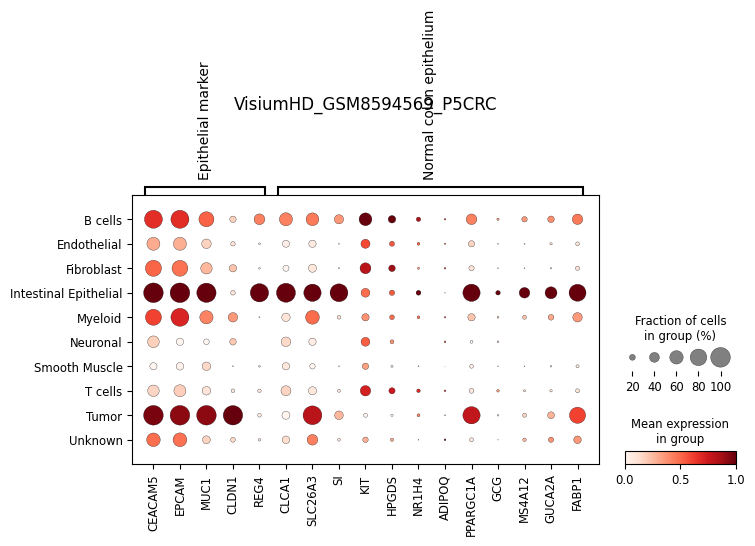

Plotting for sample: VisiumHD_GSM8594568_P2CRC


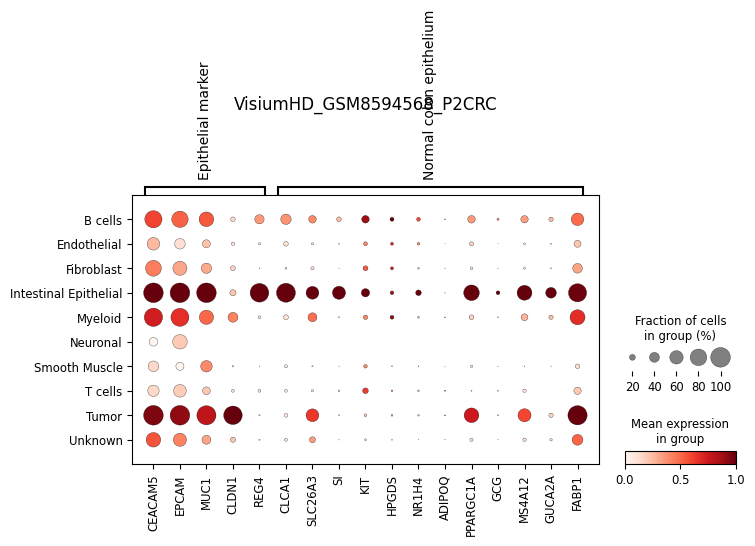

In [17]:
for s in adata_merged.obs['sample'].unique():
    print(f"Plotting for sample: {s}")
    adata_sub = adata_merged[adata_merged.obs['sample'] == s]
    sc.pl.dotplot(
        adata_sub, 
        existing_genes, 
        groupby="UnsupervisedL1", 
        standard_scale="var", 
        title=s
    )

# Corelation analysis

/tmp/ipykernel_3297328/3741609450.py:107: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1., 0.95])


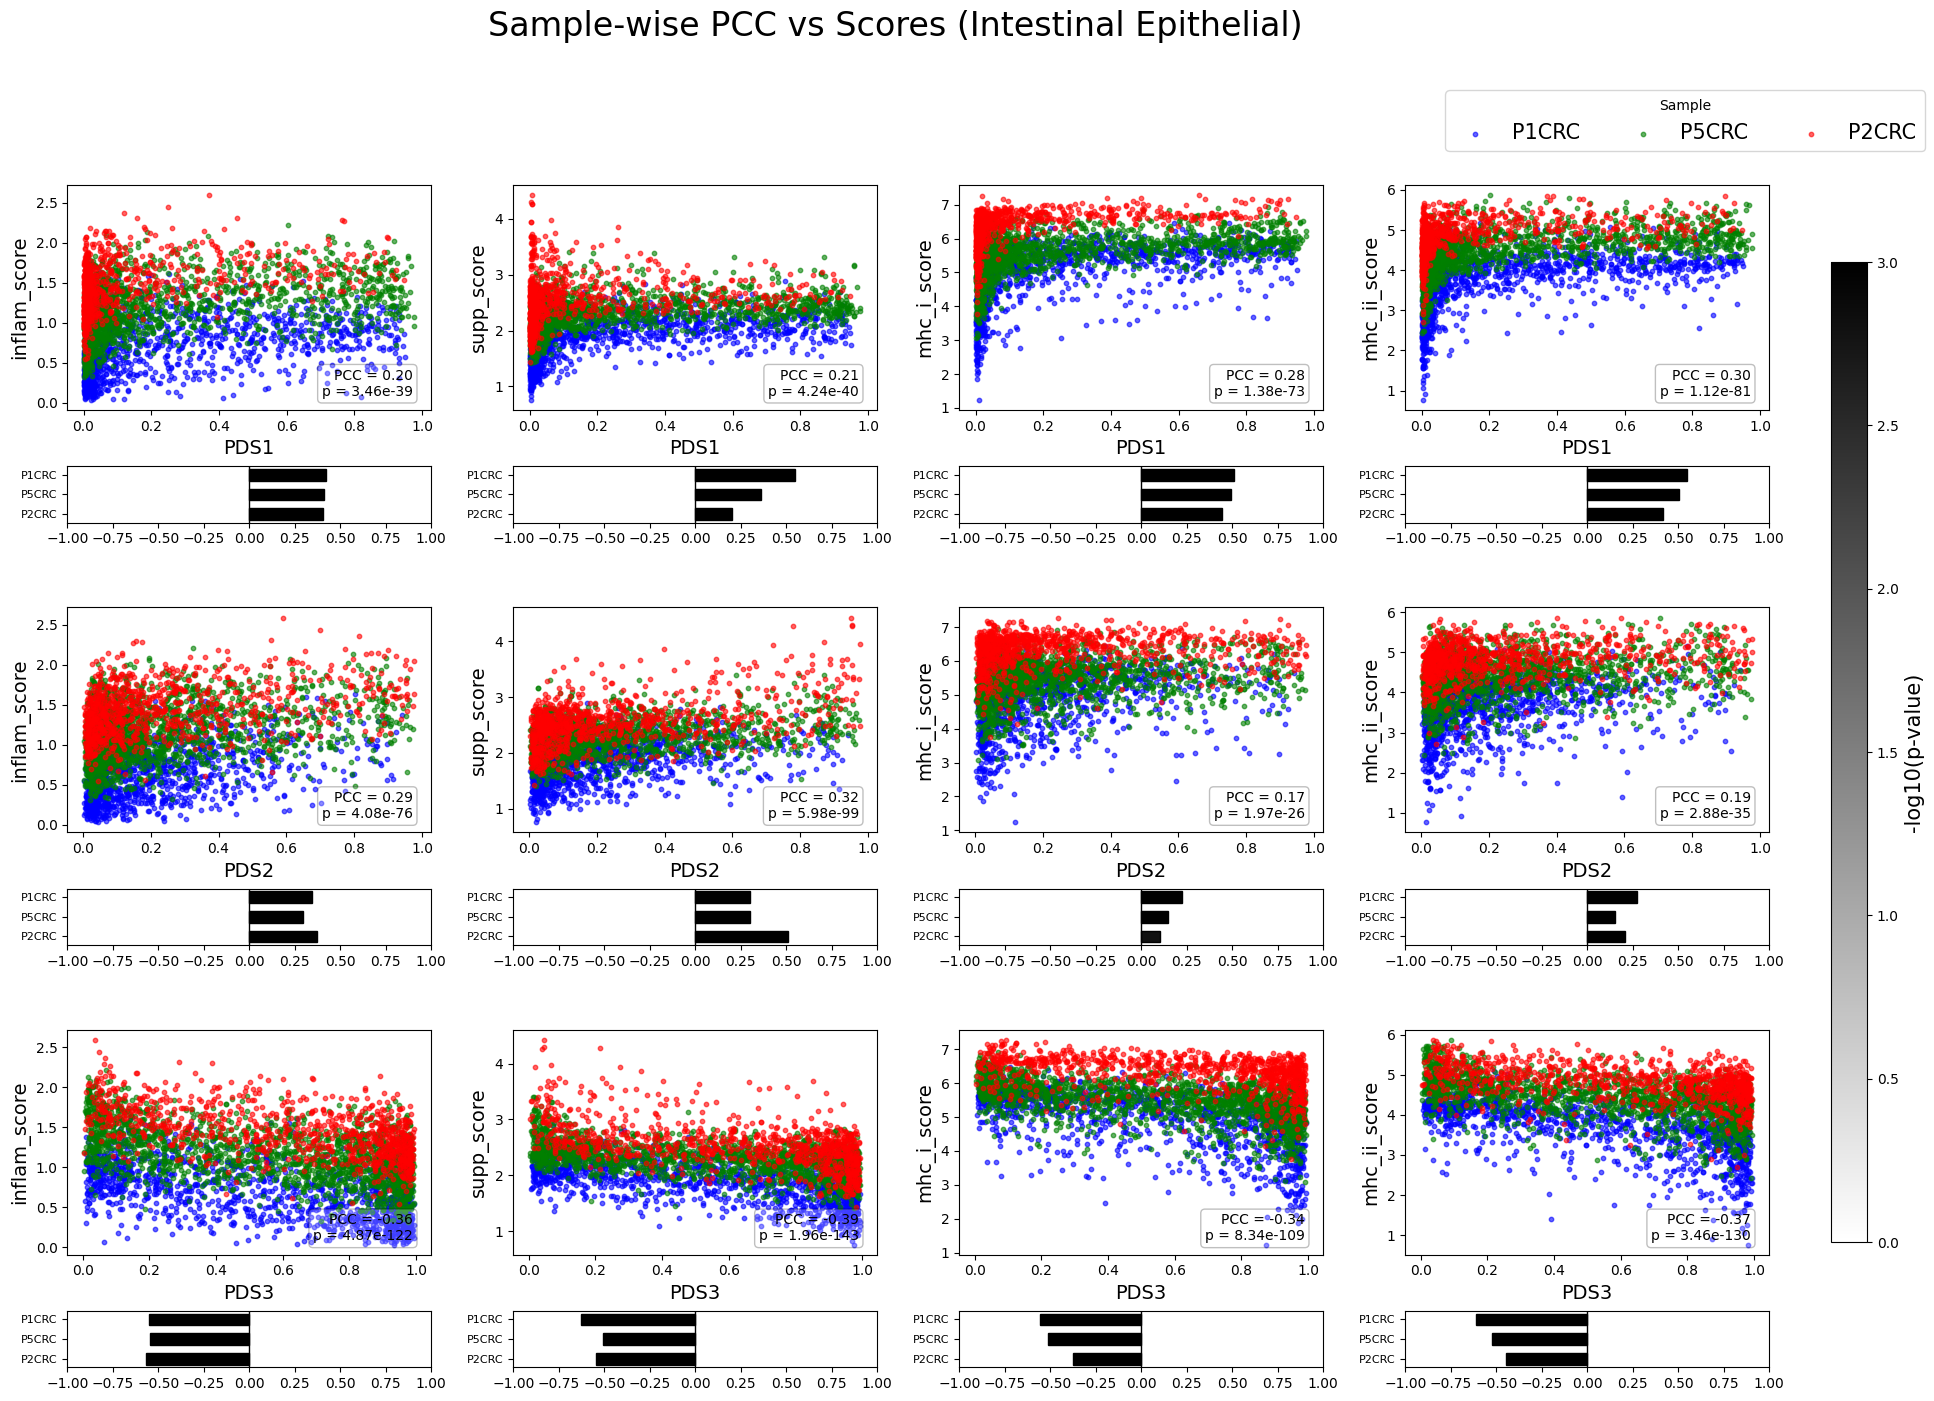

In [90]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import numpy as np
import matplotlib as mpl

# 조건 필터링
target_celltypes = ['Intestinal Epithelial']
adata_filtered = adata_merged[adata_merged.obs['UnsupervisedL1'].isin(target_celltypes)]

# x축과 y축 후보
pds_cols = ['PDS1', 'PDS2', 'PDS3']
score_cols = ['inflam_score', 'supp_score', 'mhc_i_score', 'mhc_ii_score']

# 샘플 이름
sample_names = list(sample_colors.keys())

# p-value 색상맵 (검정~하양)
cmap = plt.cm.gray_r
norm = mpl.colors.Normalize(vmin=0, vmax=3)  # -log10(p) 범위: 0 ~ 3

# subplot 설정
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(18, 14), sharex=False, sharey=False)
scatter_handles = {}

for row_idx, x_col in enumerate(pds_cols):
    for col_idx, y_col in enumerate(score_cols):
        ax = axes[row_idx, col_idx]

        # 샘플별 scatter + correlation
        sample_corrs = {}
        sample_pvals = {}
        for sample_name, color in sample_colors.items():
            sample_data = adata_filtered.obs[adata_filtered.obs['sample'] == sample_name]
            x = sample_data[x_col].values
            y = sample_data[y_col].values

            scatter = ax.scatter(x, y, alpha=0.6, s=10, color=color)
            if sample_name not in scatter_handles:
                scatter_handles[sample_name] = scatter

            if len(x) > 1 and np.std(x) > 0 and np.std(y) > 0:
                corr, pval = pearsonr(x, y)
            else:
                corr, pval = np.nan, np.nan
            sample_corrs[sample_name] = corr
            sample_pvals[sample_name] = pval

        # 전체 데이터 PCC & p-value
        x_all = adata_filtered.obs[x_col].values
        y_all = adata_filtered.obs[y_col].values
        if len(x_all) > 1 and np.std(x_all) > 0 and np.std(y_all) > 0:
            corr_all, pval_all = pearsonr(x_all, y_all)
        else:
            corr_all, pval_all = np.nan, np.nan

        # short name (마지막 '_' 뒤)
        short_names = [name.split('_')[-1] for name in sample_names]
        short_name_str = ", ".join(short_names)

        # 라벨 & PCC 표시
        ax.set_xlabel(x_col, fontsize=14)
        ax.set_ylabel(y_col, fontsize=14)
        ax.text(
            0.95, 0.05,
            f"PCC = {corr_all:.2f}\np = {pval_all:.2e}",
            transform=ax.transAxes, fontsize=10, ha='right', va='bottom',
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.25)
        )

        # === 하단 바 plot ===
        inset_ax = ax.inset_axes([0.0, -0.5, 1.0, 0.25])  # 하단에 넓게
        inset_ax.axvline(0, color='k', linewidth=1)  # 가운데 0선
        inset_ax.set_xlim(-1, 1)  # 범위 고정
        inset_ax.set_yticks(range(len(sample_names)))
        inset_ax.set_yticklabels(short_names, fontsize=8)  # short name 표시
        inset_ax.invert_yaxis()  # 위에서 아래로 표시

        for i, sample_name in enumerate(sample_names):
            corr_val = sample_corrs[sample_name]
            pval = sample_pvals[sample_name]
            if not np.isnan(corr_val) and not np.isnan(pval):
                color_val = cmap(norm(-np.log10(pval)))
            else:
                color_val = 'grey'
            inset_ax.barh(
                i, corr_val, height=0.6, color=color_val, edgecolor='black'
            )

plt.suptitle("Sample-wise PCC vs Scores (Intestinal Epithelial)", fontsize=24, y=1.03)

# 샘플 legend
fig.legend(
    handles=[scatter_handles[name] for name in sample_colors],
    labels=[name.split('_')[-1] for name in sample_colors.keys()],
    loc='upper left', bbox_to_anchor=(0.80, 0.98),
    ncol=len(sample_colors), fontsize=15, title="Sample"
)

# p-value 색상 범례
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)

# [left, bottom, width, height]로 정확하게 위치 지정
cbar_ax = fig.add_axes([1.02, 0.15, 0.02, 0.7])  # 필요에 따라 값 조정 가능
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('-log10(p-value)', fontsize=15)

plt.tight_layout(rect=[0, 0, 1., 0.95])
plt.show()


/tmp/ipykernel_3297328/1232190733.py:107: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1., 0.95])


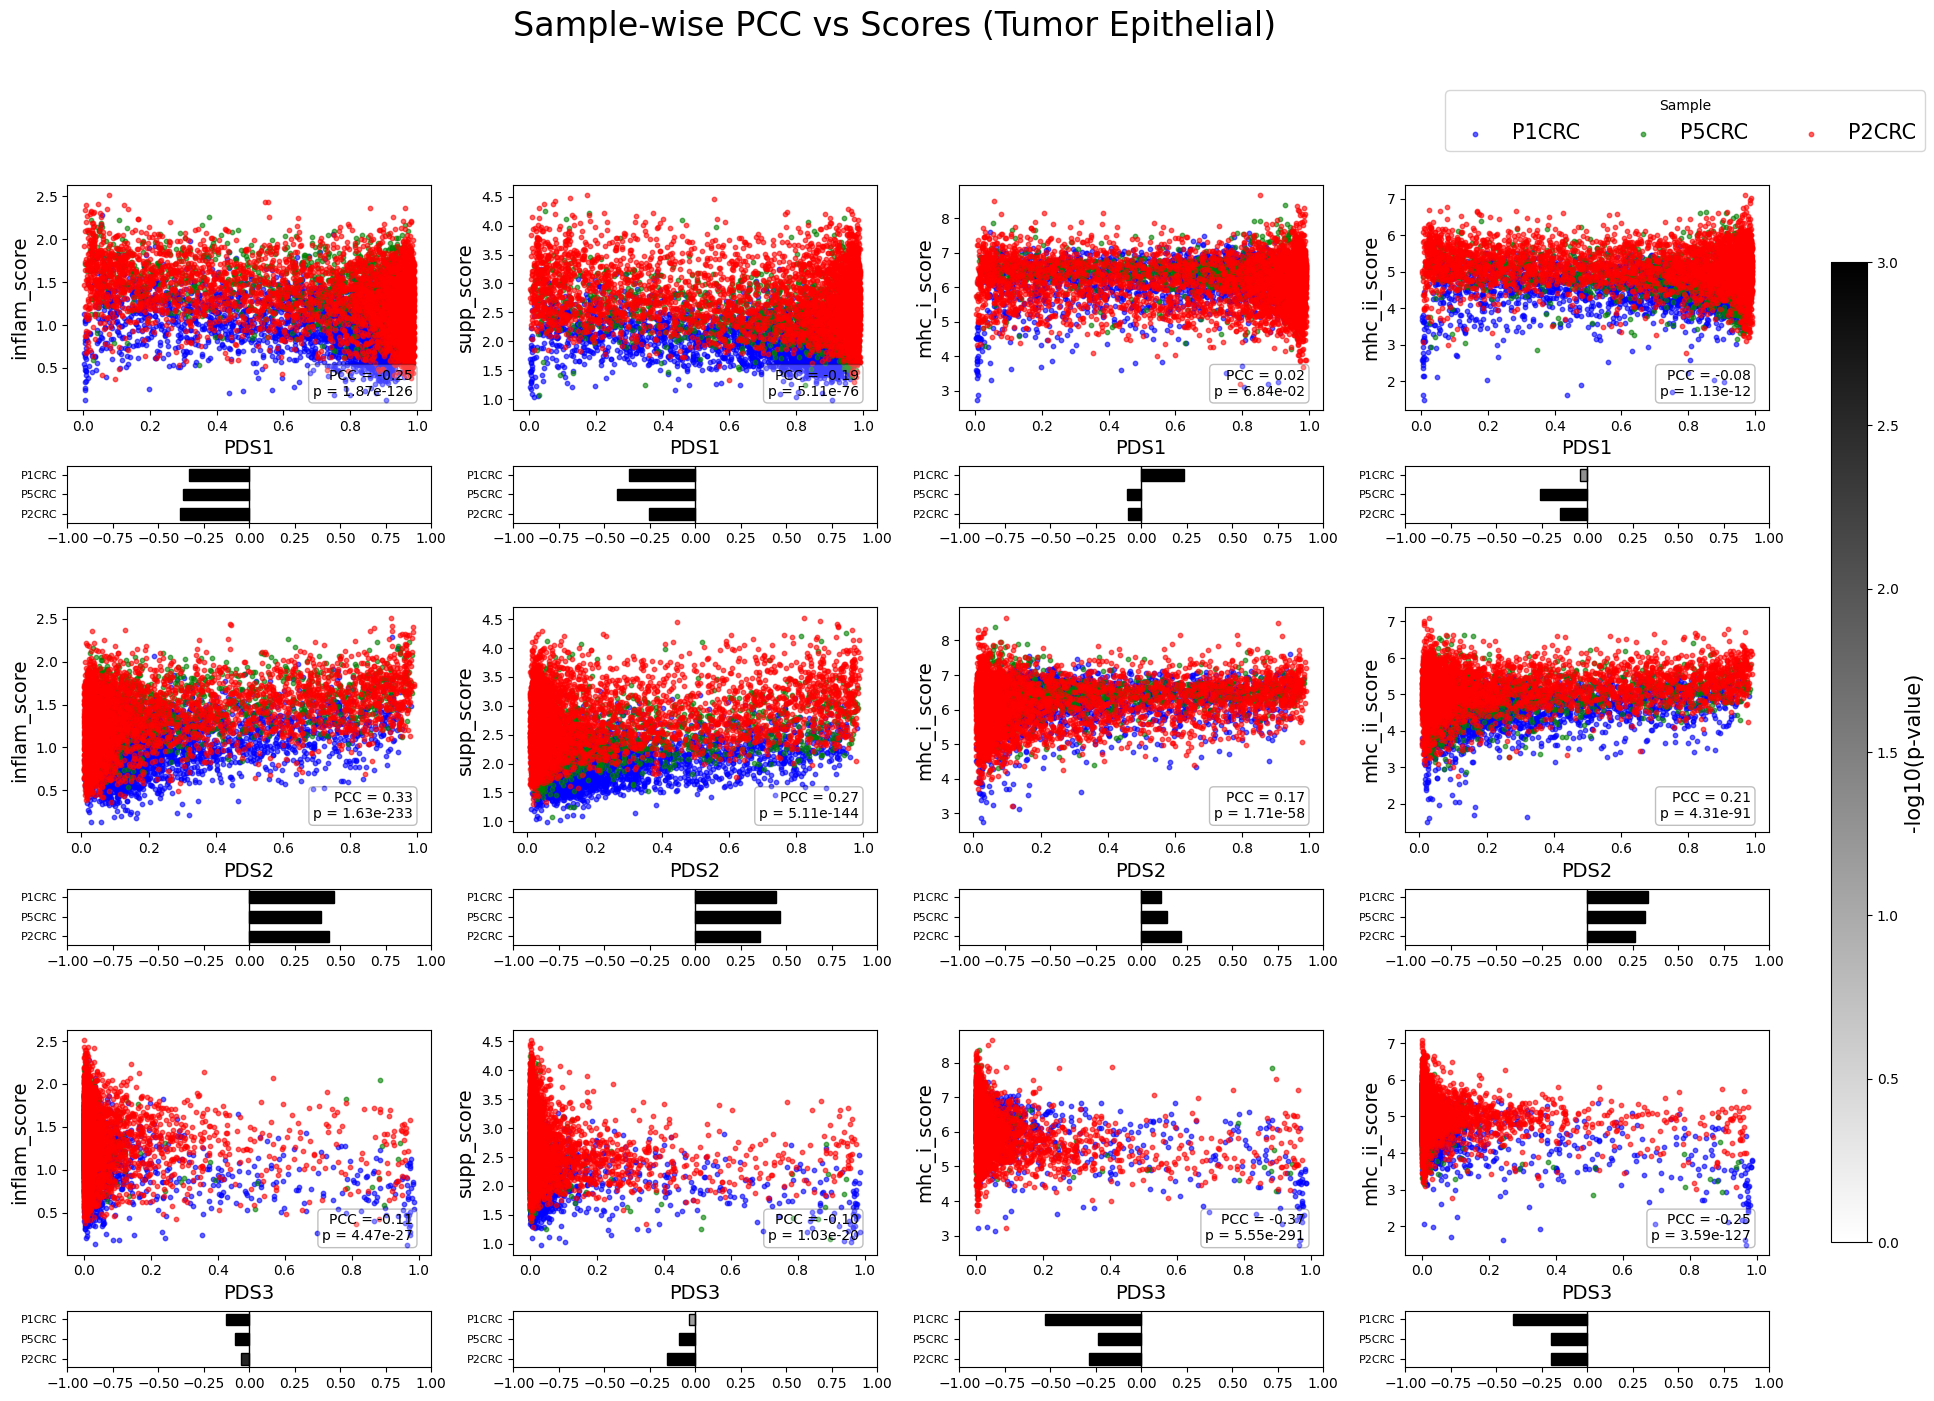

In [89]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import numpy as np
import matplotlib as mpl

# 조건 필터링
target_celltypes = ['Tumor']
adata_filtered = adata_merged[adata_merged.obs['UnsupervisedL1'].isin(target_celltypes)]

# x축과 y축 후보
pds_cols = ['PDS1', 'PDS2', 'PDS3']
score_cols = ['inflam_score', 'supp_score', 'mhc_i_score', 'mhc_ii_score']

# 샘플 이름
sample_names = list(sample_colors.keys())

# p-value 색상맵 (검정~하양)
cmap = plt.cm.gray_r
norm = mpl.colors.Normalize(vmin=0, vmax=3)  # -log10(p) 범위: 0 ~ 3

# subplot 설정
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(18, 14), sharex=False, sharey=False)
scatter_handles = {}

for row_idx, x_col in enumerate(pds_cols):
    for col_idx, y_col in enumerate(score_cols):
        ax = axes[row_idx, col_idx]

        # 샘플별 scatter + correlation
        sample_corrs = {}
        sample_pvals = {}
        for sample_name, color in sample_colors.items():
            sample_data = adata_filtered.obs[adata_filtered.obs['sample'] == sample_name]
            x = sample_data[x_col].values
            y = sample_data[y_col].values

            scatter = ax.scatter(x, y, alpha=0.6, s=10, color=color)
            if sample_name not in scatter_handles:
                scatter_handles[sample_name] = scatter

            if len(x) > 1 and np.std(x) > 0 and np.std(y) > 0:
                corr, pval = pearsonr(x, y)
            else:
                corr, pval = np.nan, np.nan
            sample_corrs[sample_name] = corr
            sample_pvals[sample_name] = pval

        # 전체 데이터 PCC & p-value
        x_all = adata_filtered.obs[x_col].values
        y_all = adata_filtered.obs[y_col].values
        if len(x_all) > 1 and np.std(x_all) > 0 and np.std(y_all) > 0:
            corr_all, pval_all = pearsonr(x_all, y_all)
        else:
            corr_all, pval_all = np.nan, np.nan

        # short name (마지막 '_' 뒤)
        short_names = [name.split('_')[-1] for name in sample_names]
        short_name_str = ", ".join(short_names)

        # 라벨 & PCC 표시
        ax.set_xlabel(x_col, fontsize=14)
        ax.set_ylabel(y_col, fontsize=14)
        ax.text(
            0.95, 0.05,
            f"PCC = {corr_all:.2f}\np = {pval_all:.2e}",
            transform=ax.transAxes, fontsize=10, ha='right', va='bottom',
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.25)
        )

        # === 하단 바 plot ===
        inset_ax = ax.inset_axes([0.0, -0.5, 1.0, 0.25])  # 하단에 넓게
        inset_ax.axvline(0, color='k', linewidth=1)  # 가운데 0선
        inset_ax.set_xlim(-1, 1)  # 범위 고정
        inset_ax.set_yticks(range(len(sample_names)))
        inset_ax.set_yticklabels(short_names, fontsize=8)  # short name 표시
        inset_ax.invert_yaxis()  # 위에서 아래로 표시

        for i, sample_name in enumerate(sample_names):
            corr_val = sample_corrs[sample_name]
            pval = sample_pvals[sample_name]
            if not np.isnan(corr_val) and not np.isnan(pval):
                color_val = cmap(norm(-np.log10(pval)))
            else:
                color_val = 'grey'
            inset_ax.barh(
                i, corr_val, height=0.6, color=color_val, edgecolor='black'
            )

plt.suptitle("Sample-wise PCC vs Scores (Tumor Epithelial)", fontsize=24, y=1.03)

# 샘플 legend
fig.legend(
    handles=[scatter_handles[name] for name in sample_colors],
    labels=[name.split('_')[-1] for name in sample_colors.keys()],
    loc='upper left', bbox_to_anchor=(0.80, 0.98),
    ncol=len(sample_colors), fontsize=15, title="Sample"
)

# p-value 색상 범례
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)

# [left, bottom, width, height]로 정확하게 위치 지정
cbar_ax = fig.add_axes([1.02, 0.15, 0.02, 0.7])  # 필요에 따라 값 조정 가능
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('-log10(p-value)', fontsize=15)

plt.tight_layout(rect=[0, 0, 1., 0.95])
plt.show()


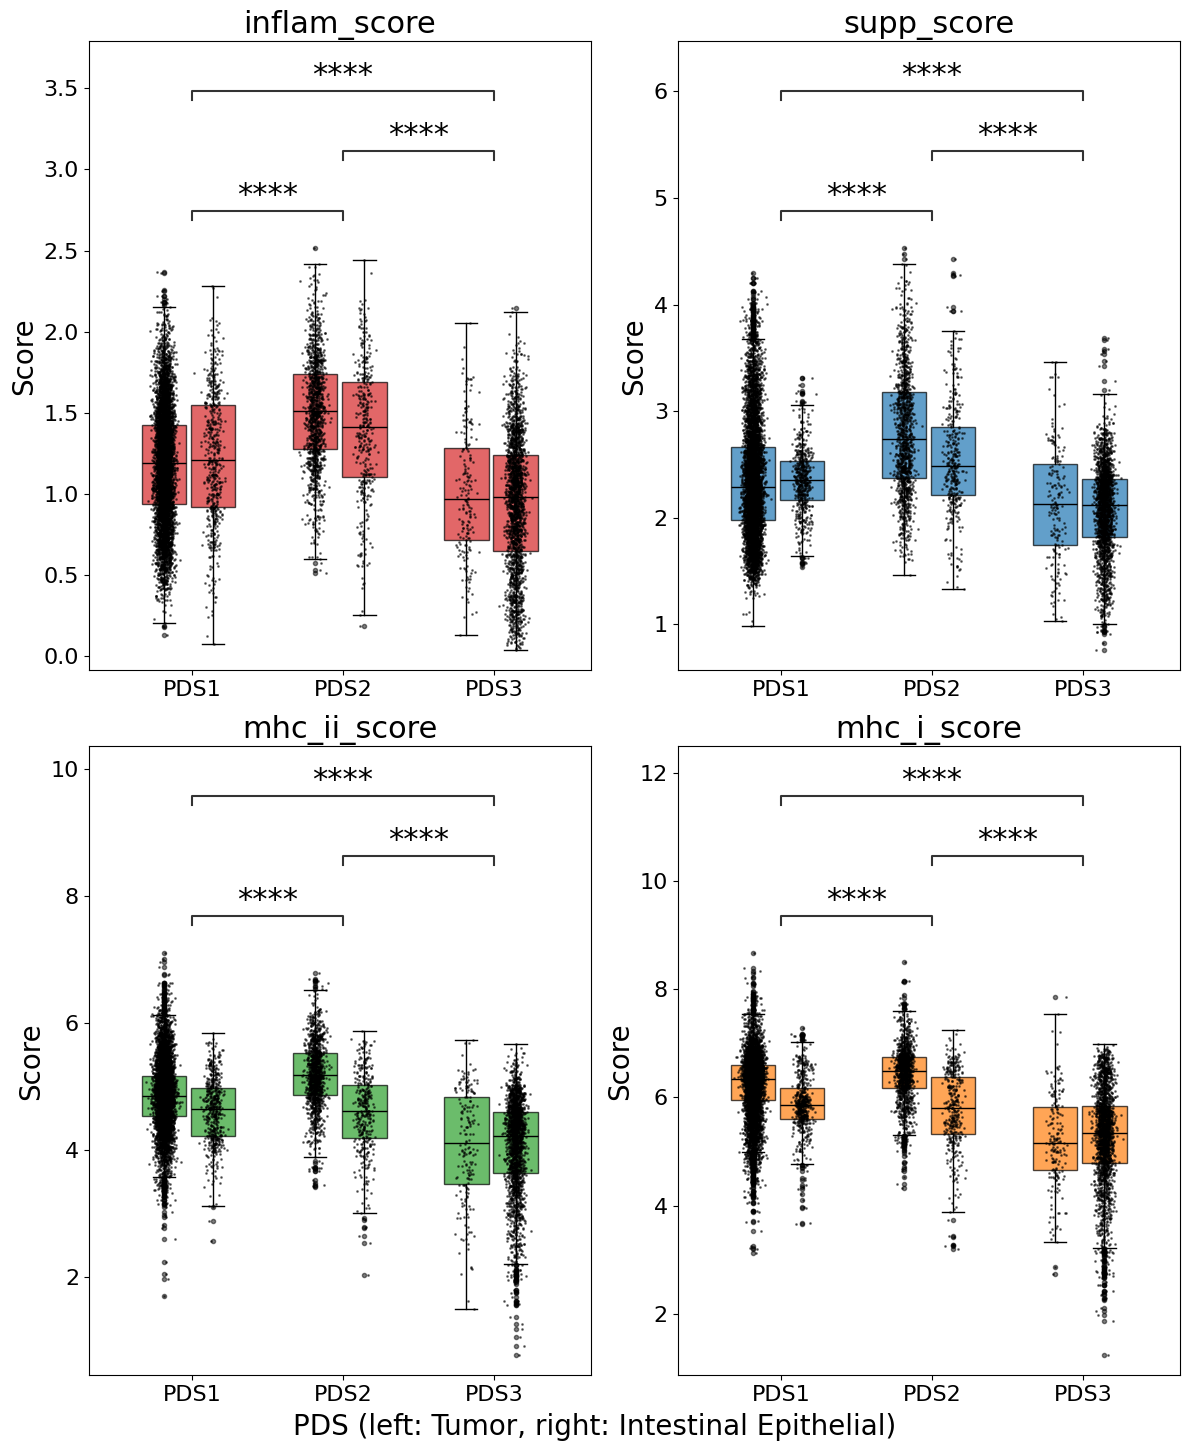

In [160]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statannotations.Annotator import Annotator
import numpy as np

def plot_box_dot_no_legend(adata, score_cols, cell_types_of_interest, pds_order,
                           box_width=0.8, jitter_scale=0.05, offset_delta=0.03):

    df = adata.obs[
        adata.obs['UnsupervisedL1'].isin(cell_types_of_interest)
    ][score_cols + ['PDS', 'UnsupervisedL1']].copy()

    comparisons = [(pds_order[i], pds_order[j]) for i in range(len(pds_order)) for j in range(i+1, len(pds_order))]

    fig, axes = plt.subplots(2, 2, figsize=(12, 15))
    axes = axes.flatten()

    score_colors = {
        'inflam_score': '#d62728',
        'supp_score': '#1f77b4',
        'mhc_ii_score': '#2ca02c',
        'mhc_i_score': '#ff7f0e'
    }

    num_hues = len(cell_types_of_interest)
    hue_offsets = np.linspace(-box_width/2 + box_width/(2*num_hues),
                              box_width/2 - box_width/(2*num_hues),
                              num_hues) - offset_delta
    hue_dict = {hue: hue_offsets[i] for i, hue in enumerate(cell_types_of_interest)}

    for idx, score in enumerate(score_cols):
        ax = axes[idx]

        # boxplot 수동 그리기 (dodge=False 대신 PDS 위치 + hue offset)
        for i, pds in enumerate(pds_order):
            for hue in cell_types_of_interest:
                y_values = df[(df['PDS'] == pds) & (df['UnsupervisedL1'] == hue)][score]
                x_base = i + hue_dict[hue]

                # 박스 수동 그리기
                ax.boxplot(
                    y_values,
                    positions=[x_base],
                    widths=box_width/num_hues * 0.9,
                    patch_artist=True,
                    boxprops=dict(facecolor=score_colors[score], color='black', alpha=0.7),
                    medianprops=dict(color='black'),
                    whiskerprops=dict(color='black'),
                    capprops=dict(color='black'),
                    flierprops=dict(marker='o', markerfacecolor='black', markersize=3, alpha=0.5)
                )

                # dot 좌표 수동 조정
                jitter = np.random.normal(loc=0, scale=jitter_scale, size=len(y_values))
                ax.scatter(x_base + jitter, y_values, color='black', s=1, alpha=0.5, zorder=10)

        # 제목, 축
        ax.set_title(score, fontsize=22)
        ax.set_ylabel("Score", fontsize=20)
        ax.set_xticks(range(len(pds_order)))
        ax.set_xticklabels(pds_order, fontsize=16)
        ax.tick_params(axis='y', labelsize=16)

        # 통계검정 annotation
        annotator = Annotator(ax, comparisons, data=df, x='PDS', y=score, order=pds_order)
        annotator.configure(
            test='t-test_ind',
            text_format='star',
            loc='inside',
            fontsize=22,
            verbose=0
        )
        annotator.apply_and_annotate()

    # 전체 figure X축 라벨 (한번만)
    fig.text(0.5, 0.04, "PDS (left: Tumor, right: Intestinal Epithelial)", ha='center', fontsize=20)

    plt.tight_layout(rect=[0, 0.05, 1, 1])  # 하단 공간 확보
    plt.show()


# 사용 예시
plot_box_dot_no_legend(
    adata=adata_merged,
    score_cols=['inflam_score', 'supp_score', 'mhc_ii_score', 'mhc_i_score'],
    cell_types_of_interest=['Tumor', 'Intestinal Epithelial'],
    pds_order=['PDS1', 'PDS2', 'PDS3'],
    box_width=0.65,      # box 폭 자유 조절 가능
    jitter_scale=0.03,  # dot 흩어짐 정도
    offset_delta=0.02   # dot 좌표 보정
)


# Pathway analysis


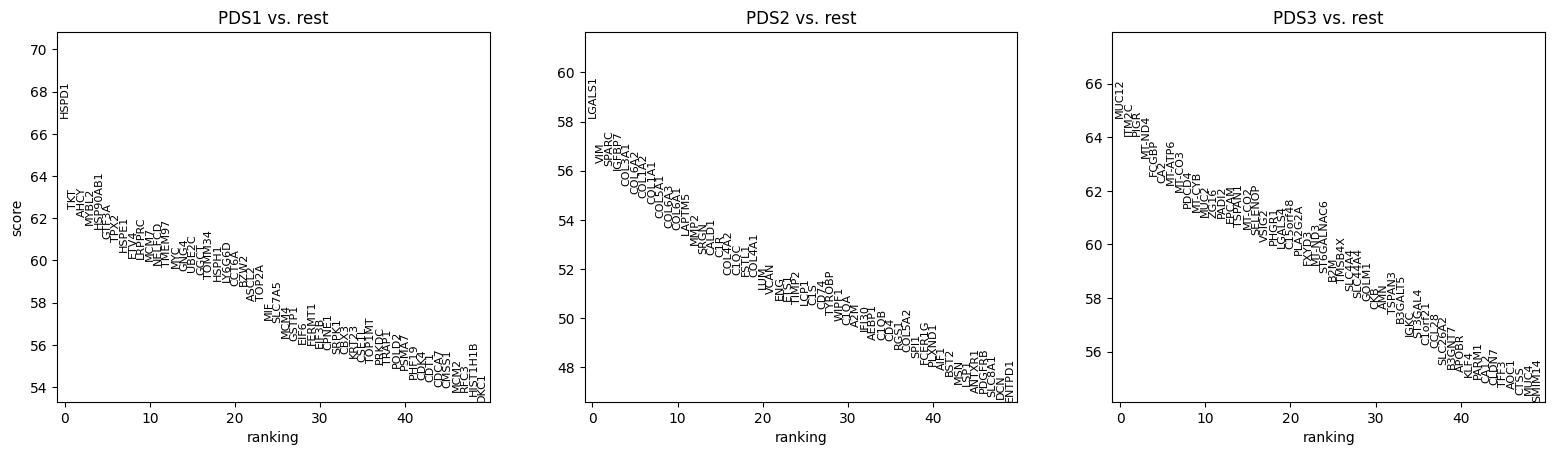

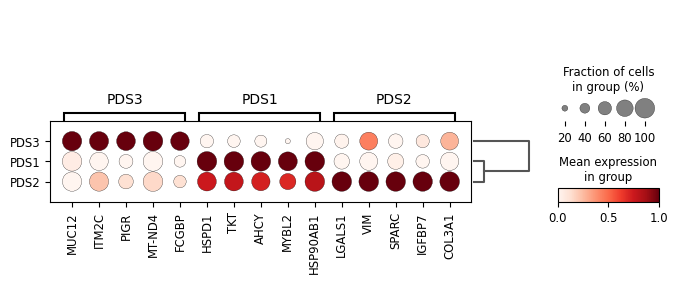

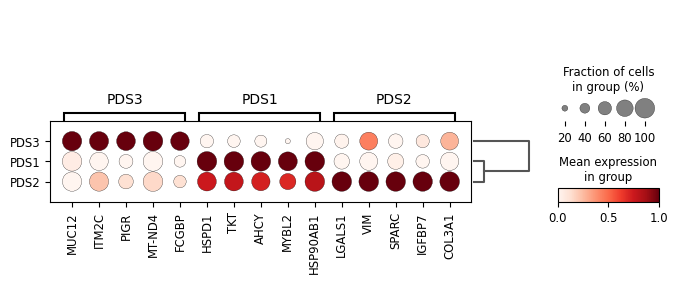

Processing genesets: 10it [00:01,  9.01it/s]                      

Error processing PDS3 for WikiPathway_2024_Human: 'WikiPathway_2024_Human'
Error processing PDS2 for WikiPathway_2024_Human: 'WikiPathway_2024_Human'
Error processing PDS1 for WikiPathway_2024_Human: 'WikiPathway_2024_Human'


Processing genesets: 15it [00:01,  8.91it/s]


Trying to re-request...
Error processing PDS1 for WikiPathway_2024_Human: 'WikiPathway_2024_Human'
PDS1 with WikiPathway_2024_Human completed!
Error processing PDS2 for WikiPathway_2024_Human: 'WikiPathway_2024_Human'
PDS2 with WikiPathway_2024_Human completed!
Error processing PDS3 for WikiPathway_2024_Human: 'WikiPathway_2024_Human'
PDS3 with WikiPathway_2024_Human completed!


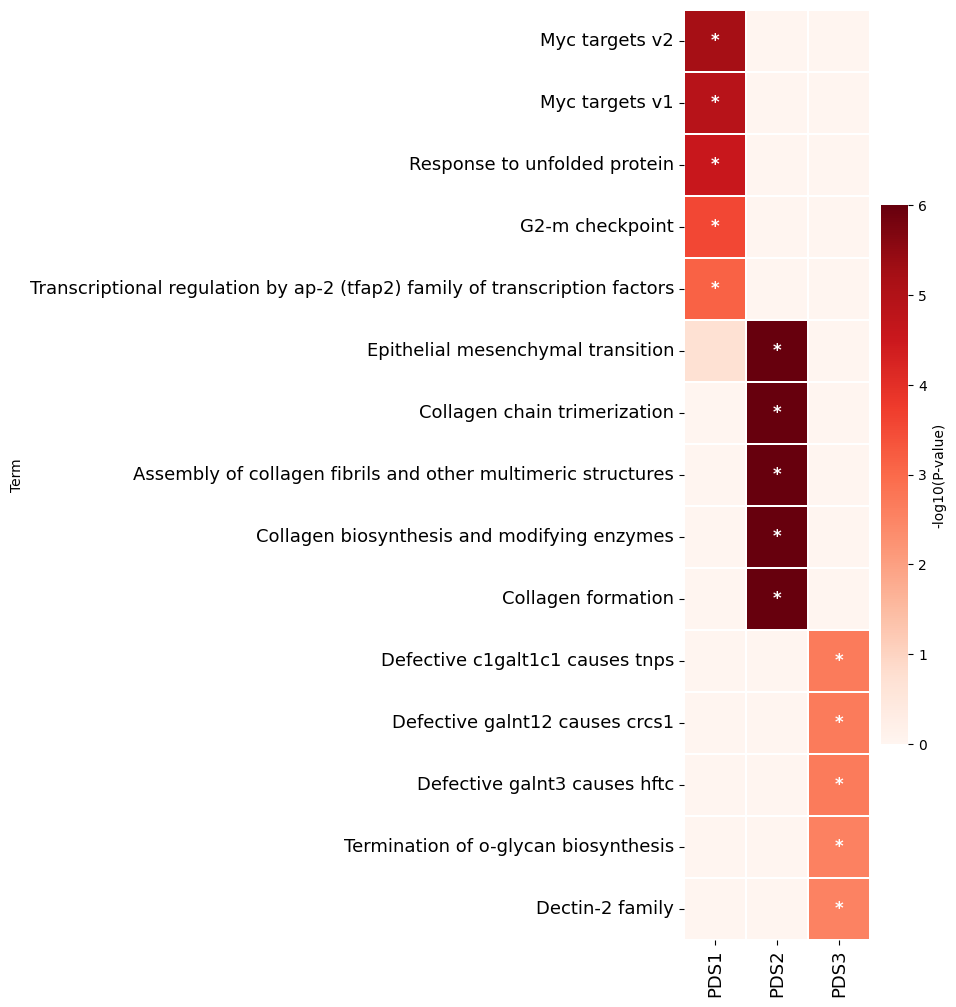

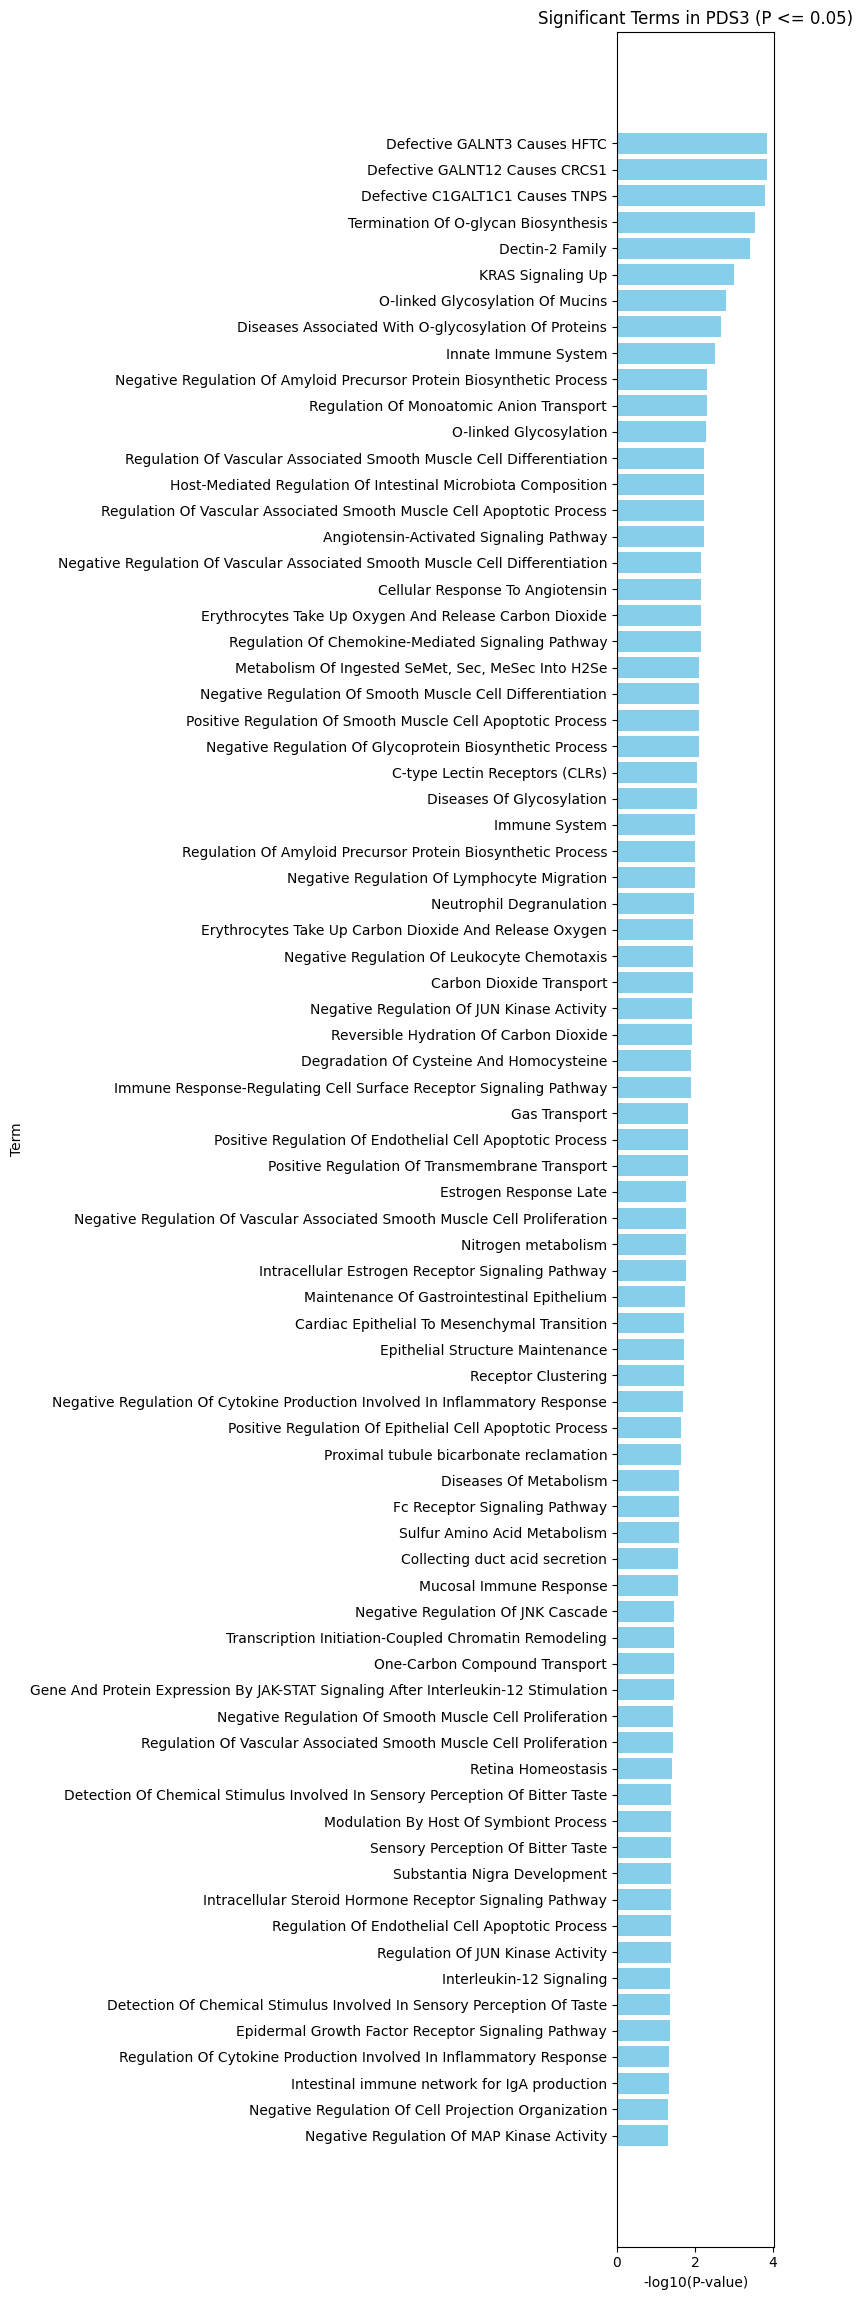

In [171]:
adata_PDS = adata_merged[
    adata_merged.obs['UnsupervisedL1'].isin(['Tumor', 'Intestinal Epithelial']) &
    adata_merged.obs['PDS'].isin(['PDS1', 'PDS2', 'PDS3'])
].copy()

sc.tl.rank_genes_groups(adata_PDS, 'PDS', method="wilcoxon",use_raw =False)
sc.pl.rank_genes_groups(adata_PDS, n_genes=50, sharey=False)
sc.tl.dendrogram(adata_PDS, groupby='PDS')
sc.pl.rank_genes_groups_dotplot(
        adata_PDS, groupby="PDS", standard_scale="var",  n_genes=5, use_raw=False
)
import pandas as pd
import scanpy as sc

# 2. 결과 저장
result = adata_PDS.uns["rank_genes_groups"]
groups = result["names"].dtype.names  # 예: ("Tcells", "Bcells", ...)

# 3. DataFrame 변환
result_df = pd.DataFrame(
    {
        f"{group}_{key}": result[key][group]
        for group in groups
        for key in ["names", "pvals_adj", "logfoldchanges", "scores"]
    }
)

# 4. 결과 저장 딕셔너리
up_dict = {}
down_dict = {}

# 5. 자동 반복 처리
for group in groups:
    n_col = f"{group}_names"
    p_col = f"{group}_pvals_adj"
    l_col = f"{group}_logfoldchanges"
    s_col = f"{group}_scores"

    degs_sig = result_df[result_df[p_col] < 0.05]
    degs_up = degs_sig[degs_sig[l_col] > 1].sort_values(by=s_col, ascending=False)
    degs_dw = degs_sig[degs_sig[l_col] < -1].sort_values(by=s_col, ascending=True)

    # 유전자 이름만 추출
    up_dict[group] = degs_up[n_col].reset_index(drop=True)
    down_dict[group] = degs_dw[n_col].reset_index(drop=True)

# 6. 병합
df_merge_up = pd.concat(up_dict.values(), axis=1)
df_merge_up.columns = list(up_dict.keys())  # 각 열 이름을 group 이름으로

df_merge_down = pd.concat(down_dict.values(), axis=1)
df_merge_down.columns = list(down_dict.keys())

sc.tl.dendrogram(adata_PDS, groupby='PDS')
sc.pl.rank_genes_groups_dotplot(
        adata_PDS, groupby="PDS", standard_scale="var",  n_genes=5, use_raw=False
)

import pandas as pd
import scanpy as sc

# 2. 결과 저장
result = adata_PDS.uns["rank_genes_groups"]
groups = result["names"].dtype.names  # 예: ("Tcells", "Bcells", ...)

# 3. DataFrame 변환
result_df = pd.DataFrame(
    {
        f"{group}_{key}": result[key][group]
        for group in groups
        for key in ["names", "pvals_adj", "logfoldchanges", "scores"]
    }
)

# 4. 결과 저장 딕셔너리
up_dict = {}
down_dict = {}

# 5. 자동 반복 처리
for group in groups:
    n_col = f"{group}_names"
    p_col = f"{group}_pvals_adj"
    l_col = f"{group}_logfoldchanges"
    s_col = f"{group}_scores"

    degs_sig = result_df[result_df[p_col] < 0.05]
    degs_up = degs_sig[degs_sig[l_col] > 1].sort_values(by=s_col, ascending=False)
    degs_dw = degs_sig[degs_sig[l_col] < -1].sort_values(by=s_col, ascending=True)

    # 유전자 이름만 추출
    up_dict[group] = degs_up[n_col].reset_index(drop=True)
    down_dict[group] = degs_dw[n_col].reset_index(drop=True)

# 6. 병합
df_merge_up = pd.concat(up_dict.values(), axis=1)
df_merge_up.columns = list(up_dict.keys())  # 각 열 이름을 group 이름으로

df_merge_down = pd.concat(down_dict.values(), axis=1)
df_merge_down.columns = list(down_dict.keys())

from qed.data import readtxt, readseurat, readscanpy
from qed.data import get_enrichment_dataframes
from qed.data import merge_df
from qed.data import query
import inspect
import pandas as pd

# ✅ 사용자 정의 GeneSet 클래스
class GeneSet:
    def __init__(self, genes, name, annot=None):
        self.genes = genes
        self.name = name
        self.params = {}
        self.GO = []
        self.annot = annot or {}

# ✅ enrichment에 사용할 데이터베이스 목록
dblist = [
    'KEGG_2021_Human',
    'Reactome_2022',
    'MSigDB_Hallmark_2020',
    'GO_Biological_Process_2023',
    'WikiPathway_2024_Human'
]

# ✅ DEG 테이블 상위 20개 추출 및 저장
df_merge_up_100 = df_merge_up.head(20)
df_merge_up_100.to_csv('breast_cancer_DEG_up_leiden.csv', index=False, header=True)

# ✅ CSV 불러오기
alist = pd.read_csv('breast_cancer_DEG_up_leiden.csv')

# ✅ 각 열마다 GeneSet 객체로 변환
geneset_list = []
for col in alist.columns:
    genes = alist[col].dropna().tolist()
    gs = GeneSet(genes=genes, name=col, annot={"Leiden": col})
    geneset_list.append(gs)

# ✅ enrichment 실행
aalist = get_enrichment_dataframes(
    geneset_list=geneset_list,
    dblist=dblist,
    annot_colname="Leiden",
    n_jobs=None,
    handle_error=True,
    max_iter=1
)

# ✅ 결과 병합 및 후처리
df = merge_df(aalist)
df['Term'] = df['Term'].str.split(r'\(GO:').str[0].str.strip()
df['Term'] = df['Term'].str.split('R-H').str[0].str.strip()
df['Term'] = df['Term'].str.split('WP').str[0].str.strip()

from typing import List, Tuple, Dict
def heatmap_with_groupwise_ordering(df: pd.DataFrame,
                                     n: int,
                                     group_by: str,
                                     order_by: str = "Adjusted p-value",
                                     cmap: str = 'Blues',
                                     xlabel_rotation: int = 90,
                                     xlabel_fontsize: int = 15,
                                     ylabel_fontsize: int = 15,
                                     figsize: Tuple = (15, 10),
                                     vmin: float = None,
                                     vmax: float = None,
                                     cbar_kws: Dict = None,
                                     linewidths: float = 0.1,
                                     title: str = None,
                                     save_to_file: str = None,
                                     enable_column_order: bool = False,
                                     column_order: list = None,
                                     enable_highlight_columns: bool = False,
                                     highlight_column_names: list = None):

    if not isinstance(df, pd.DataFrame):
        raise TypeError("입력 'df'는 pandas DataFrame이어야 합니다.")
    if group_by not in df.columns:
        raise ValueError(f"'{group_by}' 컬럼이 DataFrame에 존재하지 않습니다.")
    if order_by not in df.columns:
        raise ValueError(f"'{order_by}' 컬럼이 DataFrame에 존재하지 않습니다.")
    if 'Term' not in df.columns:
        raise ValueError("'Term' 컬럼이 DataFrame에 존재하지 않습니다.")

    has_overlapping_genes = 'Overlapping genes' in df.columns

    # P-value 컬럼 숫자형 강제 변환
    df_copy = df.copy()
    df_copy[order_by] = pd.to_numeric(df_copy[order_by], errors='coerce')
    df = df_copy

    df['Term_lower'] = df['Term'].str.lower()

    # 상위 n개 Term 추출
    df_filtered_by_order = df[df[order_by].notna()]
    df_ranked_per_group = (
        df_filtered_by_order
        .sort_values(order_by)
        .groupby(group_by)
        .head(n)
        .reset_index(drop=True)
    )
    if df_ranked_per_group.empty:
        print(f"⚠️ 각 그룹에서 상위 {n}개의 Term을 선택할 수 없습니다.")
        return None, None

    all_selected_terms_lower = df_ranked_per_group['Term_lower'].unique()

    # Overlapping genes 처리
    overlapping_genes_pivot = pd.DataFrame()
    if has_overlapping_genes:
        overlapping_genes_df = df[df['Term_lower'].isin(all_selected_terms_lower)][['Term_lower', group_by, 'Overlapping genes']]
        overlapping_genes_df['Overlapping genes'] = overlapping_genes_df['Overlapping genes'].apply(
            lambda x: ', '.join(map(str, x)) if isinstance(x, list) else str(x)
        )
        overlapping_genes_df = overlapping_genes_df.groupby(['Term_lower', group_by])['Overlapping genes'].apply(', '.join).reset_index()
        overlapping_genes_df.rename(columns={'Term_lower': 'Term'}, inplace=True)
        overlapping_genes_pivot = overlapping_genes_df.pivot(index='Term', columns=group_by, values='Overlapping genes').fillna('')
        overlapping_genes_pivot.index = overlapping_genes_pivot.index.map(lambda x: x.capitalize())

    # P-value pivot table
    aggregated_df = df[df['Term_lower'].isin(all_selected_terms_lower)].groupby(['Term_lower', group_by], as_index=False)[order_by].min()
    aggregated_df.rename(columns={'Term_lower': 'Term'}, inplace=True)
    pivot_df = aggregated_df.pivot(index="Term", columns=group_by, values=order_by).fillna(1).rename_axis(None, axis=1)

    # Log 변환
    is_pvalue_column = order_by.lower() in ['adjusted p-value', 'p-value']
    pivot_df_for_heatmap = -np.log10(np.maximum(pivot_df, np.finfo(float).eps)) if is_pvalue_column else pivot_df.copy()
    pivot_df_for_heatmap.index = pivot_df_for_heatmap.index.map(lambda x: x.capitalize())

    # ✅ Overlapping genes와 결합
    final_pivot_df = pd.concat([pivot_df_for_heatmap, overlapping_genes_pivot], axis=1)

    if save_to_file:
        try:
            final_pivot_df.to_csv(save_to_file, encoding='utf-8-sig')
            print(f"✅ 히트맵 데이터 저장 완료: '{save_to_file}'")
        except Exception as e:
            print(f"❌ 저장 실패: {e}")

    # ✅ column_order 기준 row 정렬
    row_order = []
    seen_terms = set()

    if enable_column_order and column_order:
        group_order_for_plot = [group for group in column_order if group in df[group_by].unique()]
    else:
        group_order_for_plot = df[group_by].unique()

    for group in group_order_for_plot:
        current_group_terms = df_ranked_per_group[df_ranked_per_group[group_by] == group].sort_values(order_by)
        for term_lower_val in current_group_terms['Term_lower']:
            capitalized_term = term_lower_val.capitalize()
            if capitalized_term in pivot_df_for_heatmap.index and capitalized_term not in seen_terms:
                row_order.append(capitalized_term)
                seen_terms.add(capitalized_term)

    clustered_data = final_pivot_df.loc[row_order]
    heatmap_data = clustered_data.select_dtypes(include=[np.number])
   # 1️⃣ 사용자 지정 column_order가 있으면 그 순서 적용
    if enable_column_order and column_order:
        valid_cols = [c for c in column_order if c in heatmap_data.columns]
        if valid_cols:
            heatmap_data = heatmap_data[valid_cols]

# 2️⃣ column_order가 없고, 열 이름이 전부 숫자로 해석 가능하면 오름차순 정렬
    else:
        try:
        # 모든 열 이름을 float으로 바꿔 보고 성공하면 오름차순 재정렬
            numeric_col_keys = [float(c) for c in heatmap_data.columns]
            sorted_cols = [col for _, col in sorted(zip(numeric_col_keys, heatmap_data.columns))]
            heatmap_data = heatmap_data[sorted_cols]
        except ValueError:
        # 열 이름이 숫자가 아닌 게 섞여 있으면 그대로 둡니다
            pass


    if is_pvalue_column:
        p_values_for_annotation = 10 ** (-np.clip(heatmap_data, None, 300))
        annotations = np.where(p_values_for_annotation <= 0.05, '*', '')
        annotations = annotations.astype(object)
    else:
        annotations = False

    # ✅ 열 강조 인덱스 계산 (선 추가)
    highlight_column_indices = []
    if enable_highlight_columns and highlight_column_names:
        highlight_column_indices = [
            list(heatmap_data.columns).index(col)
            for col in highlight_column_names if col in heatmap_data.columns
        ]

    # ✅ 시각화
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(heatmap_data, cmap=cmap, vmin=vmin, vmax=vmax,
                linewidths=linewidths, annot=annotations, fmt='',
                linecolor='white', ax=ax, cbar_kws=cbar_kws, square=True,
                annot_kws={"size": 12, "color": "white", "weight": "bold"})

    # 수직선 추가
    for x in highlight_column_indices:
        ax.vlines(x + 1, *ax.get_ylim(), colors='black', linewidth=2)

    plt.xticks(rotation=xlabel_rotation, fontsize=xlabel_fontsize)
    plt.yticks(fontsize=ylabel_fontsize)
    if title:
        ax.set_title(title, fontsize=18, pad=20)
    plt.grid(False)

    if 'Term_lower' in df.columns:
        df.drop(columns='Term_lower', inplace=True)

    return fig, ax

fig, ax = heatmap_with_groupwise_ordering(
    df= df,
    n=5,
    group_by='Leiden',
    order_by="Adjusted p-value",
    cmap='Reds',
    xlabel_rotation=90,
    xlabel_fontsize=13,
    ylabel_fontsize=13,
    figsize=(3, 14),
    vmin=0, vmax=6,
    cbar_kws={'shrink': 0.5, 'label': '-log10(P-value)'},
    enable_column_order=False,
   # column_order=[
   #     "Contractile cardiomyocyte", 
   #     "Myogenerative cardiomyocyte", 
   #     "Inflammatory cardiomyocyte"
   # ],
    enable_highlight_columns=False,
   # highlight_column_names=[
   #     "Contractile cardiomyocyte", 
   #     "Inflammatory cardiomyocyte"
   # ]
)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_significant_terms(df, leiden_value='PDS3', pvalue_thresh=0.05):
    # 필터링
    df_filtered = df[(df['Leiden'] == leiden_value) & (df['P-value'] <= pvalue_thresh)].copy()
    
    if df_filtered.empty:
        print("조건을 만족하는 Term이 없습니다.")
        return
    
    # P-value를 -log10 변환 (옵션)
    df_filtered['neg_log10_p'] = -np.log10(df_filtered['P-value'])
    
    # y축 Term 순서를 P-value 기준으로 정렬
    df_filtered = df_filtered.sort_values('neg_log10_p', ascending=True)
    
    # figure 크기 조절 (Term 개수에 따라)
    plt.figure(figsize=(8, max(4, 0.3*len(df_filtered))))
    
    plt.barh(df_filtered['Term'], df_filtered['neg_log10_p'], color='skyblue')
    plt.xlabel('-log10(P-value)')
    plt.ylabel('Term')
    plt.title(f'Significant Terms in {leiden_value} (P <= {pvalue_thresh})')
    
    plt.tight_layout()
    plt.show()


plot_significant_terms(df)


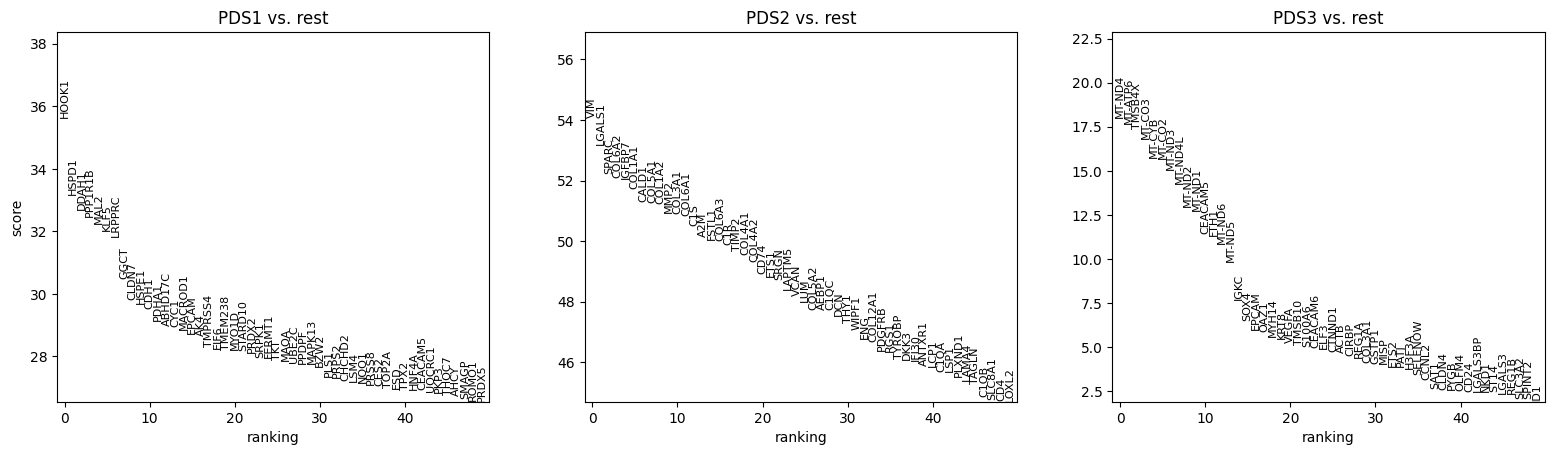

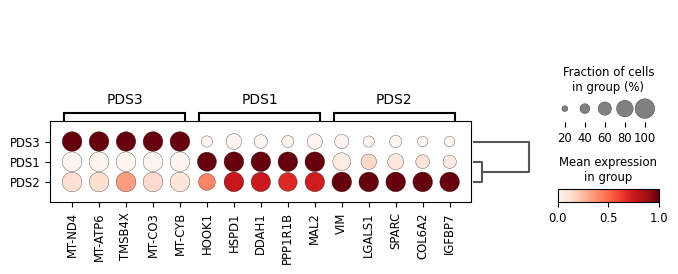

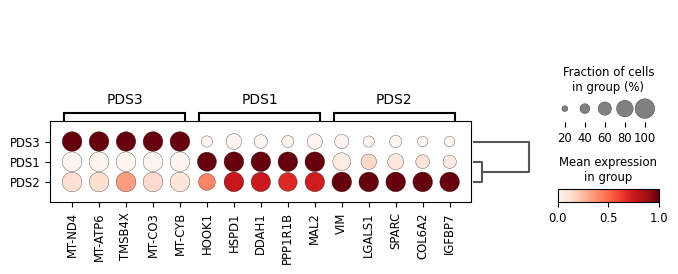

Processing genesets: 15it [01:00,  4.04s/it]                      

Error processing PDS1 for KEGG_2021_Human: Error analyzing gene list
Error processing PDS1 for GO_Biological_Process_2023: Error analyzing gene list
Error processing PDS2 for KEGG_2021_Human: Error analyzing gene list
Error processing PDS1 for Reactome_2022: Error analyzing gene list
Error processing PDS1 for MSigDB_Hallmark_2020: Error analyzing gene list
Error processing PDS2 for MSigDB_Hallmark_2020: Error analyzing gene list
Error processing PDS3 for KEGG_2021_Human: Error analyzing gene list
Error processing PDS2 for GO_Biological_Process_2023: Error analyzing gene list
Error processing PDS3 for GO_Biological_Process_2023: Error analyzing gene list
Error processing PDS3 for WikiPathway_2024_Human: Error analyzing gene list
Error processing PDS1 for WikiPathway_2024_Human: Error analyzing gene list
Error processing PDS2 for Reactome_2022: Error analyzing gene list
Error processing PDS3 for MSigDB_Hallmark_2020: Error analyzing gene list
Error processing PDS3 for Reactome_2022: Erro

Error processing PDS1 for KEGG_2021_Human: Error analyzing gene list
PDS1 with KEGG_2021_Human completed!
Error processing PDS1 for Reactome_2022: Error analyzing gene list
PDS1 with Reactome_2022 completed!
Error processing PDS1 for MSigDB_Hallmark_2020: Error analyzing gene list
PDS1 with MSigDB_Hallmark_2020 completed!
PDS1 with GO_Biological_Process_2023 completed!
Error processing PDS1 for WikiPathway_2024_Human: 'WikiPathway_2024_Human'
PDS1 with WikiPathway_2024_Human completed!
PDS2 with KEGG_2021_Human completed!
PDS2 with Reactome_2022 completed!
PDS2 with MSigDB_Hallmark_2020 completed!
PDS2 with GO_Biological_Process_2023 completed!
Error processing PDS2 for WikiPathway_2024_Human: 'WikiPathway_2024_Human'
PDS2 with WikiPathway_2024_Human completed!
PDS3 with KEGG_2021_Human completed!
PDS3 with Reactome_2022 completed!
PDS3 with MSigDB_Hallmark_2020 completed!
PDS3 with GO_Biological_Process_2023 completed!
Error processing PDS3 for WikiPathway_2024_Human: 'WikiPathway_202

/home/Data_Drive_8TB/kykim/QED/qed/data/structure.py:35: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  merged_df = pd.concat(geneset.GO, axis=0, ignore_index=True)


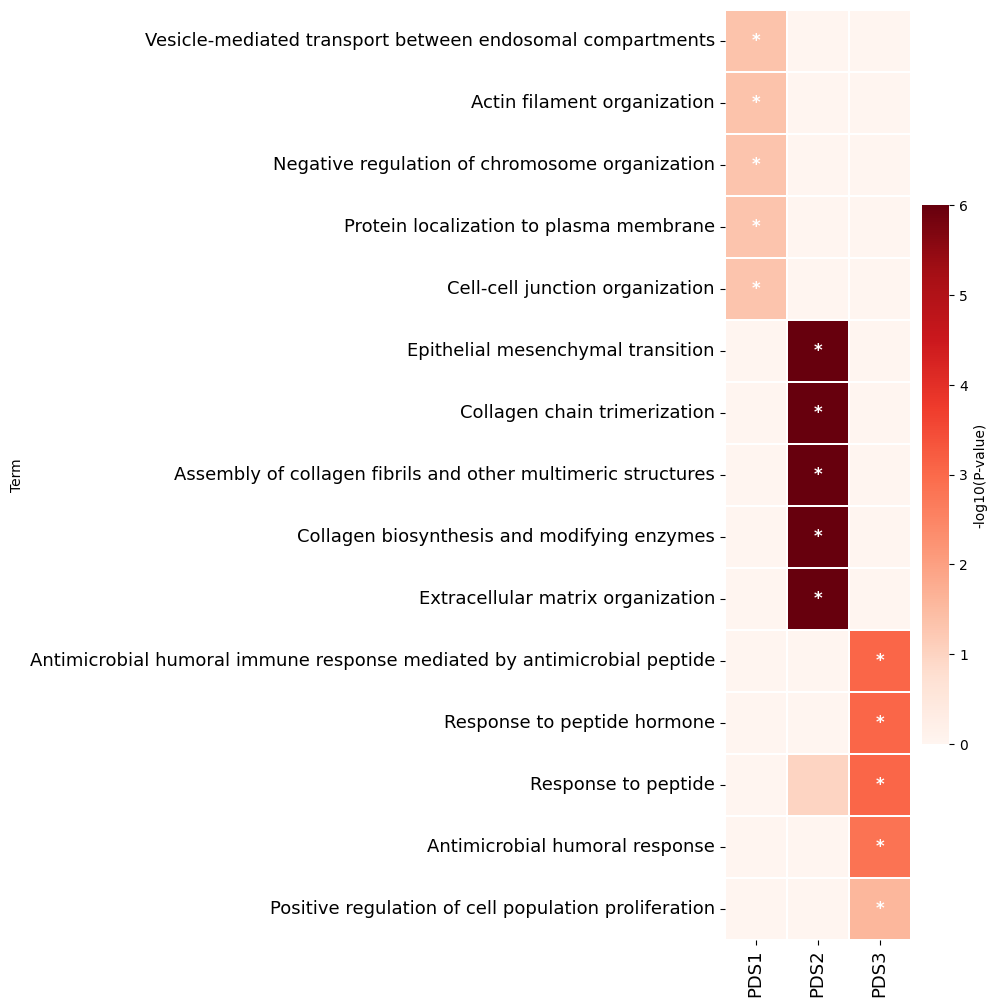

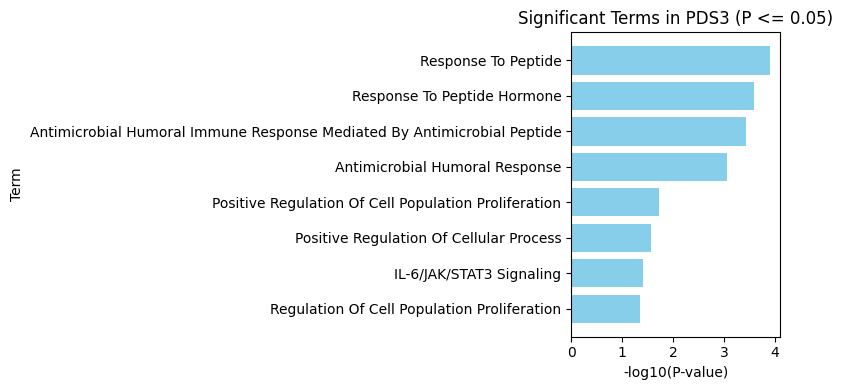

In [215]:
from typing import List, Any
import concurrent.futures
import copy
from tqdm import tqdm
from qed.data.query import get_enrichment_data

adata_PDS = adata_merged[
    adata_merged.obs['UnsupervisedL1'].isin(['Tumor']) &
    adata_merged.obs['PDS'].isin(['PDS1', 'PDS2', 'PDS3'])
].copy()

sc.tl.rank_genes_groups(adata_PDS, 'PDS', method="wilcoxon",use_raw =False)
sc.pl.rank_genes_groups(adata_PDS, n_genes=50, sharey=False)
sc.tl.dendrogram(adata_PDS, groupby='PDS')
sc.pl.rank_genes_groups_dotplot(
        adata_PDS, groupby="PDS", standard_scale="var",  n_genes=5, use_raw=False
)
import pandas as pd
import scanpy as sc

# 2. 결과 저장
result = adata_PDS.uns["rank_genes_groups"]
groups = result["names"].dtype.names  # 예: ("Tcells", "Bcells", ...)

# 3. DataFrame 변환
result_df = pd.DataFrame(
    {
        f"{group}_{key}": result[key][group]
        for group in groups
        for key in ["names", "pvals_adj", "logfoldchanges", "scores"]
    }
)

# 4. 결과 저장 딕셔너리
up_dict = {}
down_dict = {}

# 5. 자동 반복 처리
for group in groups:
    n_col = f"{group}_names"
    p_col = f"{group}_pvals_adj"
    l_col = f"{group}_logfoldchanges"
    s_col = f"{group}_scores"

    degs_sig = result_df[result_df[p_col] < 0.05]
    degs_up = degs_sig[degs_sig[l_col] > 1].sort_values(by=s_col, ascending=False)
    degs_dw = degs_sig[degs_sig[l_col] < -1].sort_values(by=s_col, ascending=True)

    # 유전자 이름만 추출
    up_dict[group] = degs_up[n_col].reset_index(drop=True)
    down_dict[group] = degs_dw[n_col].reset_index(drop=True)

# 6. 병합
df_merge_up = pd.concat(up_dict.values(), axis=1)
df_merge_up.columns = list(up_dict.keys())  # 각 열 이름을 group 이름으로

df_merge_down = pd.concat(down_dict.values(), axis=1)
df_merge_down.columns = list(down_dict.keys())

sc.tl.dendrogram(adata_PDS, groupby='PDS')
sc.pl.rank_genes_groups_dotplot(
        adata_PDS, groupby="PDS", standard_scale="var",  n_genes=5, use_raw=False
)

import pandas as pd
import scanpy as sc

# 2. 결과 저장
result = adata_PDS.uns["rank_genes_groups"]
groups = result["names"].dtype.names  # 예: ("Tcells", "Bcells", ...)

# 3. DataFrame 변환
result_df = pd.DataFrame(
    {
        f"{group}_{key}": result[key][group]
        for group in groups
        for key in ["names", "pvals_adj", "logfoldchanges", "scores"]
    }
)

# 4. 결과 저장 딕셔너리
up_dict = {}
down_dict = {}

# 5. 자동 반복 처리
for group in groups:
    n_col = f"{group}_names"
    p_col = f"{group}_pvals_adj"
    l_col = f"{group}_logfoldchanges"
    s_col = f"{group}_scores"

    degs_sig = result_df[result_df[p_col] < 0.05]
    degs_up = degs_sig[degs_sig[l_col] > 1].sort_values(by=s_col, ascending=False)
    degs_dw = degs_sig[degs_sig[l_col] < -1].sort_values(by=s_col, ascending=True)

    # 유전자 이름만 추출
    up_dict[group] = degs_up[n_col].reset_index(drop=True)
    down_dict[group] = degs_dw[n_col].reset_index(drop=True)

# 6. 병합
df_merge_up = pd.concat(up_dict.values(), axis=1)
df_merge_up.columns = list(up_dict.keys())  # 각 열 이름을 group 이름으로

df_merge_down = pd.concat(down_dict.values(), axis=1)
df_merge_down.columns = list(down_dict.keys())

from qed.data import readtxt, readseurat, readscanpy
from qed.data import get_enrichment_dataframes
from qed.data import merge_df
from qed.data import query
import inspect
import pandas as pd

# ✅ 사용자 정의 GeneSet 클래스
class GeneSet:
    def __init__(self, genes, name, annot=None):
        self.genes = genes
        self.name = name
        self.params = {}
        self.GO = []
        self.annot = annot or {}

# ✅ enrichment에 사용할 데이터베이스 목록
dblist = [
    'KEGG_2021_Human',
    'Reactome_2022',
    'MSigDB_Hallmark_2020',
    'GO_Biological_Process_2023',
    'WikiPathway_2024_Human'
]

# ✅ DEG 테이블 상위 20개 추출 및 저장
df_merge_up_100 = df_merge_up.head(20)
df_merge_up_100.to_csv('breast_cancer_DEG_up_leiden.csv', index=False, header=True)

# ✅ CSV 불러오기
alist = pd.read_csv('breast_cancer_DEG_up_leiden.csv')

# ✅ 각 열마다 GeneSet 객체로 변환
geneset_list = []
for col in alist.columns:
    genes = alist[col].dropna().tolist()
    gs = GeneSet(genes=genes, name=col, annot={"Leiden": col})
    geneset_list.append(gs)
##########################


# def get_enrichment_dataframes_spare(geneset_list :List[geneset], 
#                                     dblist: List, annot_colname: str, 
#                                     annot: Any = None):
    
#     print_lock = Lock()

#     with concurrent.futures.ThreadPoolExecutor() as executor:
#         for geneset in geneset_list:
#             futures = {executor.submit(_get_multiple_enrichment_data, 
#                                        geneset, 
#                                        database, 
#                                        annot_colname, 
#                                        annot): database for database in dblist}
#             concurrent.futures.wait(futures)
            
#             with print_lock:
#                 print(f'{geneset.name} completed!')
    
#     with print_lock :    
#         print(f'All process completed!')

#     return geneset_list

    
##########################
def get_enrichment_dataframes(geneset_list: List,
                              dblist: List,
                              annot_colname: str,
                              annot: Any = None,
                              n_jobs: int = None,
                              handle_error: bool = False,
                              max_iter: int = 10):
    
    _geneset_list = copy.deepcopy(geneset_list)

    for geneset in _geneset_list:
        geneset.params['database'] = dblist

    with concurrent.futures.ThreadPoolExecutor(max_workers=n_jobs) as executor:
        futures = {executor.submit(_get_multiple_enrichment_data, 
                                   geneset, 
                                   database, 
                                   annot_colname, 
                                   annot): geneset for geneset in _geneset_list for database in dblist}
        
        pbar = tqdm(total=len(geneset_list), desc='Processing genesets')
        
        for future in concurrent.futures.as_completed(futures):

            geneset = futures[future]
            pbar.update(1)
        
    pbar.close()


    # Re-request for geneset that has error
    if handle_error :

        print('Trying to re-request...')

        geneset_list_2 = copy.deepcopy(_geneset_list)

        for geneset in geneset_list_2:
            
            len_success = len(geneset.GO)
            db_successs = [
    df['Database'].values[0]
    for df in geneset.GO
    if not df.empty  # ✅ 빈 DataFrame은 무시
]
            retry_db = [db for db in geneset.params['database'] if db not in db_successs]

            if len_success < len(geneset.params['database']) :
                geneset.params['re_request'] = retry_db
            else :
                geneset.params['re_request'] = []

        if all([len(geneset.params['re_request']) == 0 for geneset in geneset_list_2]):
            print("Nothing to re-request")

        max_iter = max_iter
        iter_count = 0

        while any([len(geneset.params['re_request']) > 0 for geneset in geneset_list_2]) and iter_count < max_iter :

            for geneset in geneset_list_2:
                
                for database in geneset.params['re_request']:
                    
                    _get_multiple_enrichment_data(geneset, 
                                                  database, 
                                                  annot_colname, 
                                                  annot)

                    print(f'{geneset.name} with {database} completed!')

            for geneset in geneset_list_2:
                
                len_success = len(geneset.GO)
                db_successs = [
    df['Database'].values[0]
    for df in geneset.GO
    if not df.empty  # ✅ 빈 DataFrame은 무시
]
                retry_db = [db for db in geneset.params['re_request'] if db not in db_successs]

                if len_success < len(geneset.params['database']) :
                    geneset.params['re_request'] = retry_db
                else :
                    geneset.params['re_request'] = []

            iter_count += 1

    return geneset_list_2 if handle_error else _geneset_list
##########################

def _get_multiple_enrichment_data(geneset: "GeneSet",
                                  database: str, 
                                  annot_colname: str, 
                                  annot: Any = None):
    
    try:
        annot = annot if annot is not None else geneset.name
        result_df = get_enrichment_data(geneset.genes, database, annot_colname, annot)
        geneset.GO.append(result_df)

        geneset.params['annot_colname'] = annot_colname
        geneset.params['annot'] = annot
    
    except Exception as e:
        
        print(f"Error processing {geneset.name} for {database}: {str(e)}")

    return geneset


##########################



##########################
#✅ enrichment 실행
aalist = get_enrichment_dataframes(
    geneset_list=geneset_list,
    dblist=dblist,
    annot_colname="Leiden",
    n_jobs=None,
    handle_error=True,
    max_iter=1
)

# ✅ 결과 병합 및 후처리
df = merge_df(aalist)
df['Term'] = df['Term'].str.split(r'\(GO:').str[0].str.strip()
df['Term'] = df['Term'].str.split('R-H').str[0].str.strip()
df['Term'] = df['Term'].str.split('WP').str[0].str.strip()

from typing import List, Tuple, Dict
def heatmap_with_groupwise_ordering(df: pd.DataFrame,
                                     n: int,
                                     group_by: str,
                                     order_by: str = "Adjusted p-value",
                                     cmap: str = 'Blues',
                                     xlabel_rotation: int = 90,
                                     xlabel_fontsize: int = 15,
                                     ylabel_fontsize: int = 15,
                                     figsize: Tuple = (15, 10),
                                     vmin: float = None,
                                     vmax: float = None,
                                     cbar_kws: Dict = None,
                                     linewidths: float = 0.1,
                                     title: str = None,
                                     save_to_file: str = None,
                                     enable_column_order: bool = False,
                                     column_order: list = None,
                                     enable_highlight_columns: bool = False,
                                     highlight_column_names: list = None):

    if not isinstance(df, pd.DataFrame):
        raise TypeError("입력 'df'는 pandas DataFrame이어야 합니다.")
    if group_by not in df.columns:
        raise ValueError(f"'{group_by}' 컬럼이 DataFrame에 존재하지 않습니다.")
    if order_by not in df.columns:
        raise ValueError(f"'{order_by}' 컬럼이 DataFrame에 존재하지 않습니다.")
    if 'Term' not in df.columns:
        raise ValueError("'Term' 컬럼이 DataFrame에 존재하지 않습니다.")

    has_overlapping_genes = 'Overlapping genes' in df.columns

    # P-value 컬럼 숫자형 강제 변환
    df_copy = df.copy()
    df_copy[order_by] = pd.to_numeric(df_copy[order_by], errors='coerce')
    df = df_copy

    df['Term_lower'] = df['Term'].str.lower()

    # 상위 n개 Term 추출
    df_filtered_by_order = df[df[order_by].notna()]
    df_ranked_per_group = (
        df_filtered_by_order
        .sort_values(order_by)
        .groupby(group_by)
        .head(n)
        .reset_index(drop=True)
    )
    if df_ranked_per_group.empty:
        print(f"⚠️ 각 그룹에서 상위 {n}개의 Term을 선택할 수 없습니다.")
        return None, None

    all_selected_terms_lower = df_ranked_per_group['Term_lower'].unique()

    # Overlapping genes 처리
    overlapping_genes_pivot = pd.DataFrame()
    if has_overlapping_genes:
        overlapping_genes_df = df[df['Term_lower'].isin(all_selected_terms_lower)][['Term_lower', group_by, 'Overlapping genes']]
        overlapping_genes_df['Overlapping genes'] = overlapping_genes_df['Overlapping genes'].apply(
            lambda x: ', '.join(map(str, x)) if isinstance(x, list) else str(x)
        )
        overlapping_genes_df = overlapping_genes_df.groupby(['Term_lower', group_by])['Overlapping genes'].apply(', '.join).reset_index()
        overlapping_genes_df.rename(columns={'Term_lower': 'Term'}, inplace=True)
        overlapping_genes_pivot = overlapping_genes_df.pivot(index='Term', columns=group_by, values='Overlapping genes').fillna('')
        overlapping_genes_pivot.index = overlapping_genes_pivot.index.map(lambda x: x.capitalize())

    # P-value pivot table
    aggregated_df = df[df['Term_lower'].isin(all_selected_terms_lower)].groupby(['Term_lower', group_by], as_index=False)[order_by].min()
    aggregated_df.rename(columns={'Term_lower': 'Term'}, inplace=True)
    pivot_df = aggregated_df.pivot(index="Term", columns=group_by, values=order_by).fillna(1).rename_axis(None, axis=1)

    # Log 변환
    is_pvalue_column = order_by.lower() in ['adjusted p-value', 'p-value']
    pivot_df_for_heatmap = -np.log10(np.maximum(pivot_df, np.finfo(float).eps)) if is_pvalue_column else pivot_df.copy()
    pivot_df_for_heatmap.index = pivot_df_for_heatmap.index.map(lambda x: x.capitalize())

    # ✅ Overlapping genes와 결합
    final_pivot_df = pd.concat([pivot_df_for_heatmap, overlapping_genes_pivot], axis=1)

    if save_to_file:
        try:
            final_pivot_df.to_csv(save_to_file, encoding='utf-8-sig')
            print(f"✅ 히트맵 데이터 저장 완료: '{save_to_file}'")
        except Exception as e:
            print(f"❌ 저장 실패: {e}")

    # ✅ column_order 기준 row 정렬
    row_order = []
    seen_terms = set()

    if enable_column_order and column_order:
        group_order_for_plot = [group for group in column_order if group in df[group_by].unique()]
    else:
        group_order_for_plot = df[group_by].unique()

    for group in group_order_for_plot:
        current_group_terms = df_ranked_per_group[df_ranked_per_group[group_by] == group].sort_values(order_by)
        for term_lower_val in current_group_terms['Term_lower']:
            capitalized_term = term_lower_val.capitalize()
            if capitalized_term in pivot_df_for_heatmap.index and capitalized_term not in seen_terms:
                row_order.append(capitalized_term)
                seen_terms.add(capitalized_term)

    clustered_data = final_pivot_df.loc[row_order]
    heatmap_data = clustered_data.select_dtypes(include=[np.number])
   # 1️⃣ 사용자 지정 column_order가 있으면 그 순서 적용
    if enable_column_order and column_order:
        valid_cols = [c for c in column_order if c in heatmap_data.columns]
        if valid_cols:
            heatmap_data = heatmap_data[valid_cols]

# 2️⃣ column_order가 없고, 열 이름이 전부 숫자로 해석 가능하면 오름차순 정렬
    else:
        try:
        # 모든 열 이름을 float으로 바꿔 보고 성공하면 오름차순 재정렬
            numeric_col_keys = [float(c) for c in heatmap_data.columns]
            sorted_cols = [col for _, col in sorted(zip(numeric_col_keys, heatmap_data.columns))]
            heatmap_data = heatmap_data[sorted_cols]
        except ValueError:
        # 열 이름이 숫자가 아닌 게 섞여 있으면 그대로 둡니다
            pass


    if is_pvalue_column:
        p_values_for_annotation = 10 ** (-np.clip(heatmap_data, None, 300))
        annotations = np.where(p_values_for_annotation <= 0.05, '*', '')
        annotations = annotations.astype(object)
    else:
        annotations = False

    # ✅ 열 강조 인덱스 계산 (선 추가)
    highlight_column_indices = []
    if enable_highlight_columns and highlight_column_names:
        highlight_column_indices = [
            list(heatmap_data.columns).index(col)
            for col in highlight_column_names if col in heatmap_data.columns
        ]

    # ✅ 시각화
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(heatmap_data, cmap=cmap, vmin=vmin, vmax=vmax,
                linewidths=linewidths, annot=annotations, fmt='',
                linecolor='white', ax=ax, cbar_kws=cbar_kws, square=True,
                annot_kws={"size": 12, "color": "white", "weight": "bold"})

    # 수직선 추가
    for x in highlight_column_indices:
        ax.vlines(x + 1, *ax.get_ylim(), colors='black', linewidth=2)

    plt.xticks(rotation=xlabel_rotation, fontsize=xlabel_fontsize)
    plt.yticks(fontsize=ylabel_fontsize)
    if title:
        ax.set_title(title, fontsize=18, pad=20)
    plt.grid(False)

    if 'Term_lower' in df.columns:
        df.drop(columns='Term_lower', inplace=True)

    return fig, ax

fig, ax = heatmap_with_groupwise_ordering(
    df= df,
    n=5,
    group_by='Leiden',
    order_by="Adjusted p-value",
    cmap='Reds',
    xlabel_rotation=90,
    xlabel_fontsize=13,
    ylabel_fontsize=13,
    figsize=(3, 14),
    vmin=0, vmax=6,
    cbar_kws={'shrink': 0.5, 'label': '-log10(P-value)'},
    enable_column_order=False,
   # column_order=[
   #     "Contractile cardiomyocyte", 
   #     "Myogenerative cardiomyocyte", 
   #     "Inflammatory cardiomyocyte"
   # ],
    enable_highlight_columns=False,
   # highlight_column_names=[
   #     "Contractile cardiomyocyte", 
   #     "Inflammatory cardiomyocyte"
   # ]
)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_significant_terms(df, leiden_value='PDS3', pvalue_thresh=0.05):
    # 필터링
    df_filtered = df[(df['Leiden'] == leiden_value) & (df['P-value'] <= pvalue_thresh)].copy()
    
    if df_filtered.empty:
        print("조건을 만족하는 Term이 없습니다.")
        return
    
    # P-value를 -log10 변환 (옵션)
    df_filtered['neg_log10_p'] = -np.log10(df_filtered['P-value'])
    
    # y축 Term 순서를 P-value 기준으로 정렬
    df_filtered = df_filtered.sort_values('neg_log10_p', ascending=True)
    
    # figure 크기 조절 (Term 개수에 따라)
    plt.figure(figsize=(8, max(4, 0.3*len(df_filtered))))
    
    plt.barh(df_filtered['Term'], df_filtered['neg_log10_p'], color='skyblue')
    plt.xlabel('-log10(P-value)')
    plt.ylabel('Term')
    plt.title(f'Significant Terms in {leiden_value} (P <= {pvalue_thresh})')
    
    plt.tight_layout()
    plt.show()


plot_significant_terms(df)


⚠️ p-value 컬럼을 'P-value'로 자동 선택했습니다.


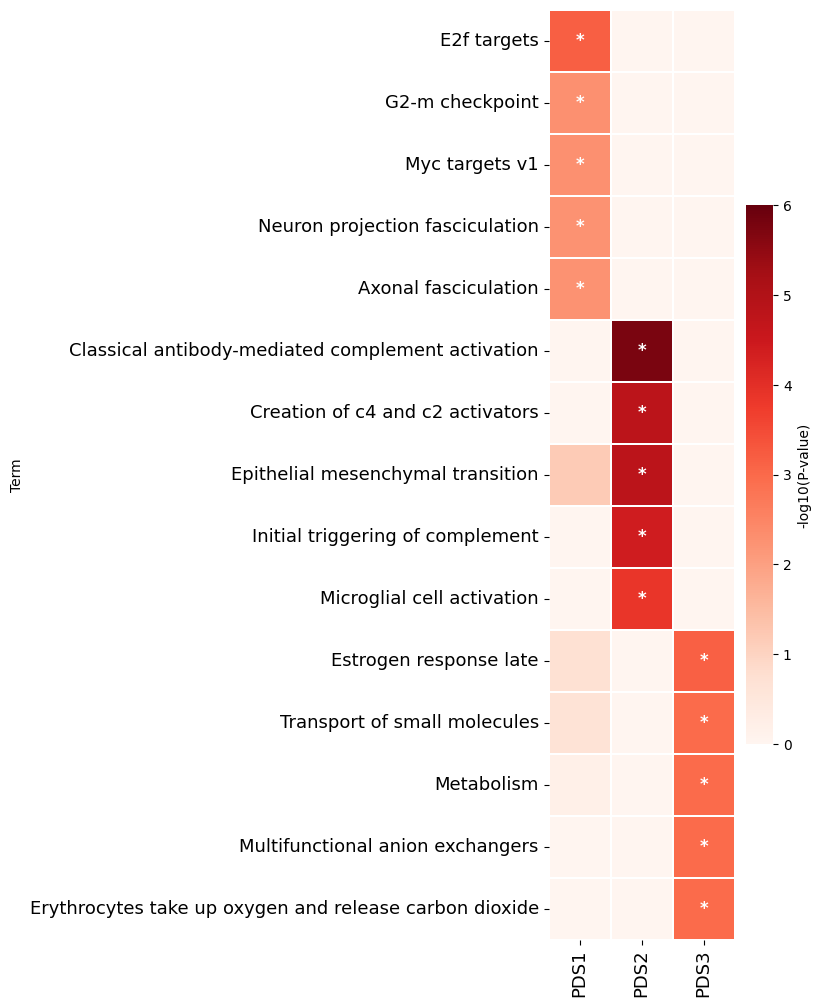

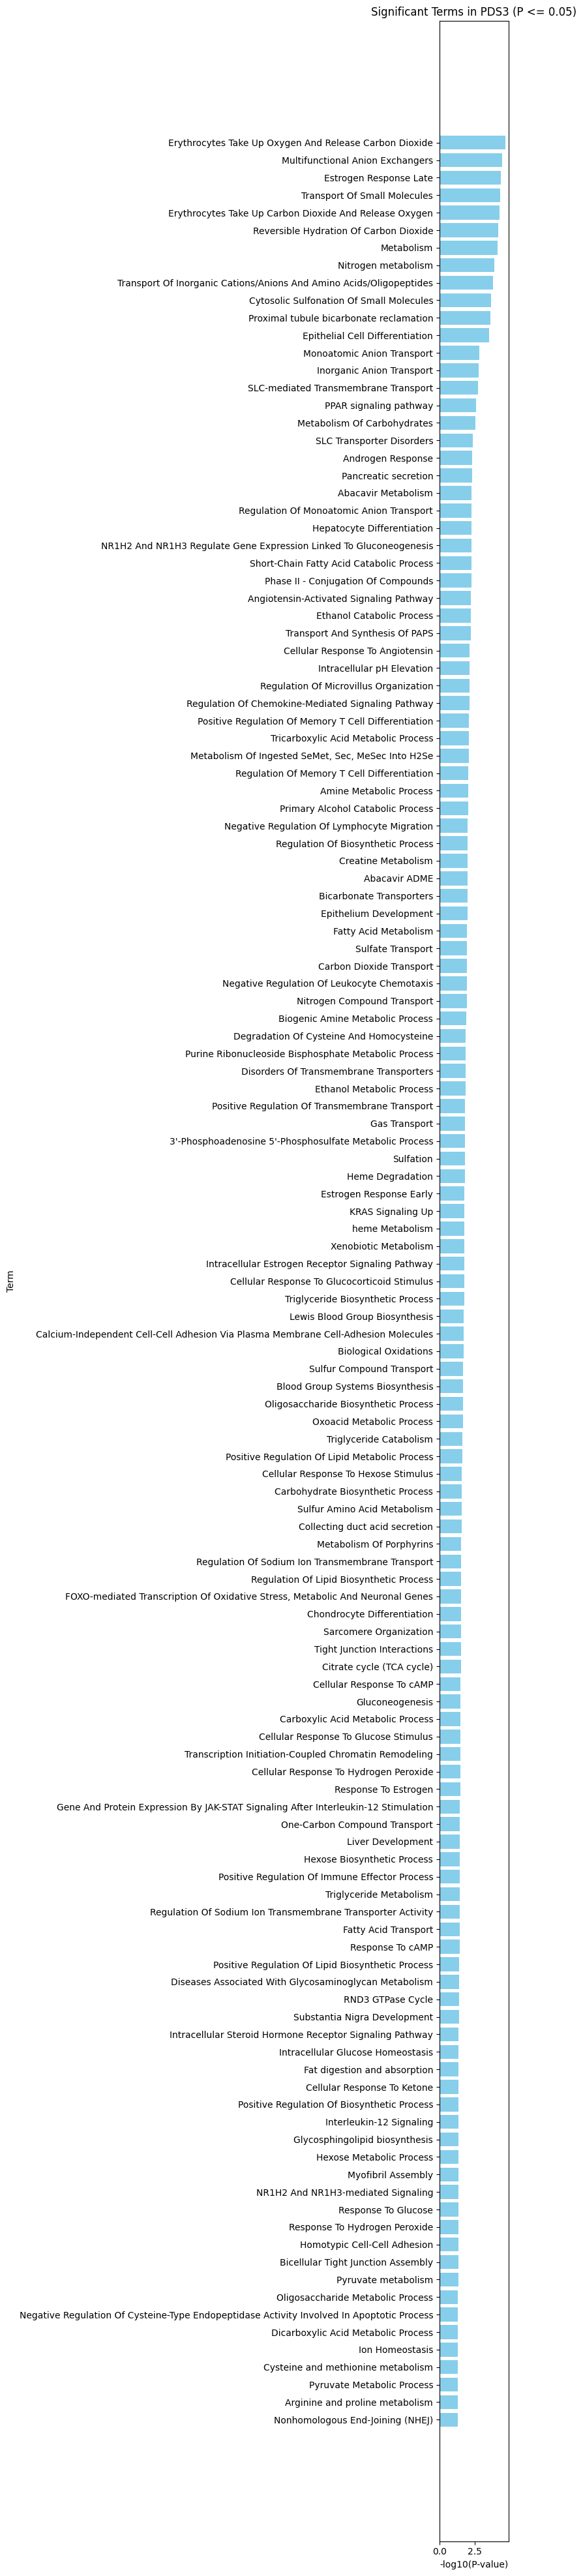

In [193]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_significant_terms(df, leiden_value='PDS3', pvalue_thresh=0.05, pvalue_col=None):
    """
    df: enrichment 결과 DataFrame
    leiden_value: Leiden 그룹 이름
    pvalue_thresh: 필터링할 p-value threshold
    pvalue_col: p-value 컬럼 이름 (자동으로 선택 가능)
    """
    # 1️⃣ p-value 컬럼 자동 선택
    if pvalue_col is None:
        possible_cols = [c for c in df.columns if 'p-value' in c.lower()]
        if not possible_cols:
            raise ValueError(f"P-value 컬럼을 찾을 수 없습니다. df.columns: {df.columns.tolist()}")
        pvalue_col = possible_cols[0]
        print(f"⚠️ p-value 컬럼을 '{pvalue_col}'로 자동 선택했습니다.")

    # 2️⃣ 필터링
    if 'Leiden' not in df.columns:
        raise ValueError("'Leiden' 컬럼이 df에 존재하지 않습니다.")
    if 'Term' not in df.columns:
        raise ValueError("'Term' 컬럼이 df에 존재하지 않습니다.")

    df_filtered = df[(df['Leiden'] == leiden_value) & (df[pvalue_col] <= pvalue_thresh)].copy()
    
    if df_filtered.empty:
        print(f"조건을 만족하는 Term이 없습니다 (Leiden={leiden_value}, {pvalue_col} <= {pvalue_thresh})")
        return

    # 3️⃣ -log10 변환
    df_filtered['neg_log10_p'] = -np.log10(df_filtered[pvalue_col].clip(lower=1e-300))

    # 4️⃣ y축 Term 정렬
    df_filtered = df_filtered.sort_values('neg_log10_p', ascending=True)

    # 5️⃣ figure 크기 조절
    plt.figure(figsize=(8, max(4, 0.3*len(df_filtered))))
    plt.barh(df_filtered['Term'], df_filtered['neg_log10_p'], color='skyblue')
    plt.xlabel(f'-log10({pvalue_col})')
    plt.ylabel('Term')
    plt.title(f'Significant Terms in {leiden_value} (P <= {pvalue_thresh})')
    plt.tight_layout()
    plt.show()


fig, ax = heatmap_with_groupwise_ordering(
    df= df,
    n=5,
    group_by='Leiden',
    order_by="Adjusted p-value",
    cmap='Reds',
    xlabel_rotation=90,
    xlabel_fontsize=13,
    ylabel_fontsize=13,
    figsize=(3, 14),
    vmin=0, vmax=6,
    cbar_kws={'shrink': 0.5, 'label': '-log10(P-value)'},
    enable_column_order=False,
   # column_order=[
   #     "Contractile cardiomyocyte", 
   #     "Myogenerative cardiomyocyte", 
   #     "Inflammatory cardiomyocyte"
   # ],
    enable_highlight_columns=False,
   # highlight_column_names=[
   #     "Contractile cardiomyocyte", 
   #     "Inflammatory cardiomyocyte"
   # ]
)



plot_significant_terms(df, leiden_value='PDS3', pvalue_thresh=0.05)


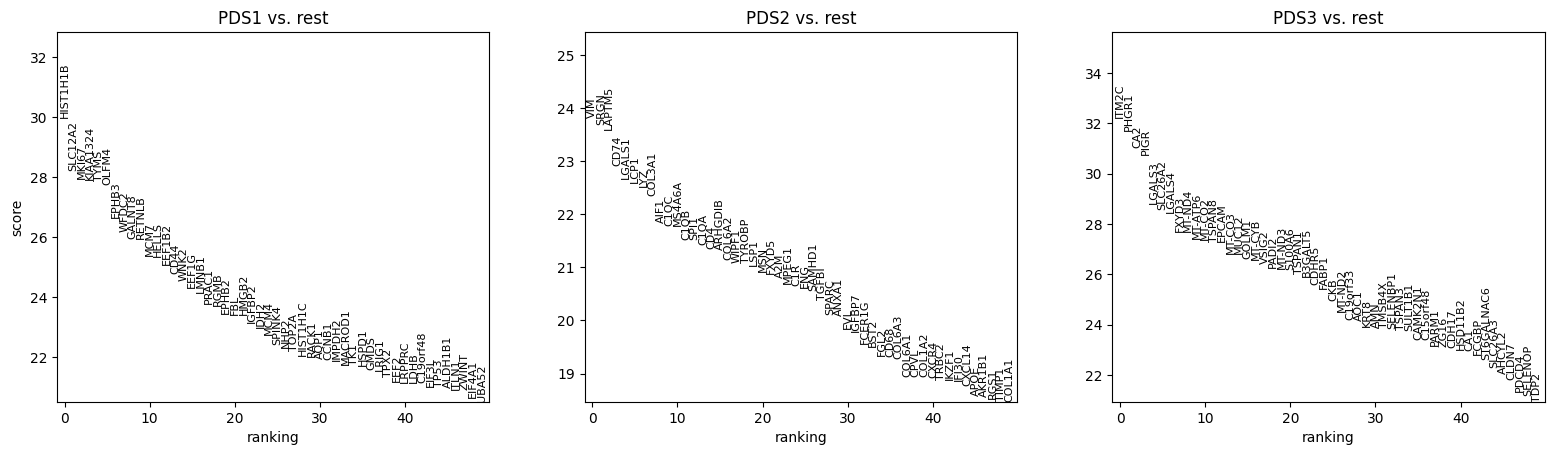

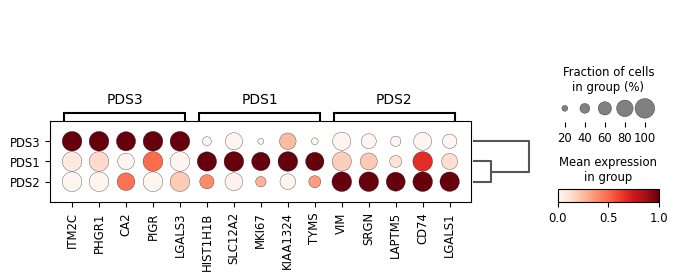

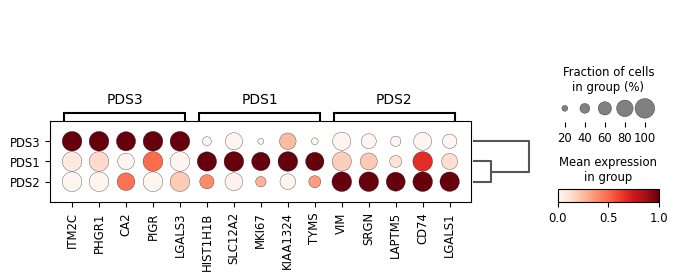

Processing genesets: 10it [00:01,  9.98it/s]                      

Error processing PDS1 for WikiPathway_2024_Human: 'WikiPathway_2024_Human'
Error processing PDS3 for WikiPathway_2024_Human: 'WikiPathway_2024_Human'
Error processing PDS2 for WikiPathway_2024_Human: 'WikiPathway_2024_Human'


Processing genesets: 15it [00:01,  9.65it/s]


Trying to re-request...
Error processing PDS1 for WikiPathway_2024_Human: 'WikiPathway_2024_Human'
PDS1 with WikiPathway_2024_Human completed!
Error processing PDS2 for WikiPathway_2024_Human: 'WikiPathway_2024_Human'
PDS2 with WikiPathway_2024_Human completed!
Error processing PDS3 for WikiPathway_2024_Human: 'WikiPathway_2024_Human'
PDS3 with WikiPathway_2024_Human completed!


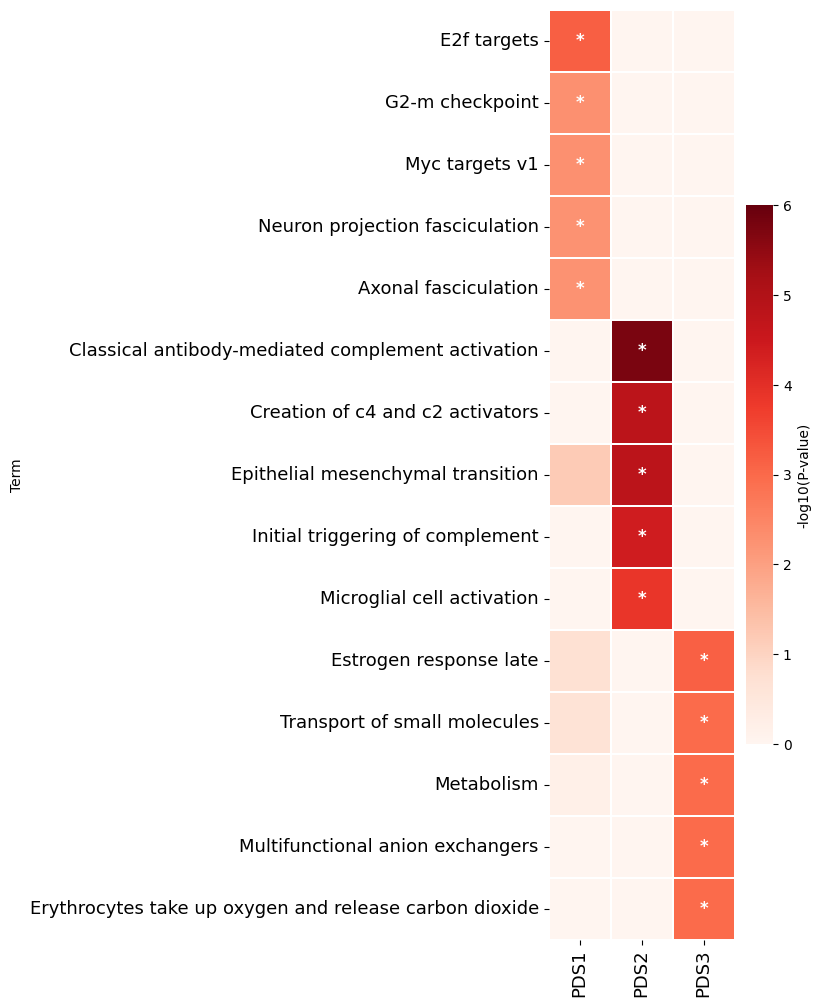

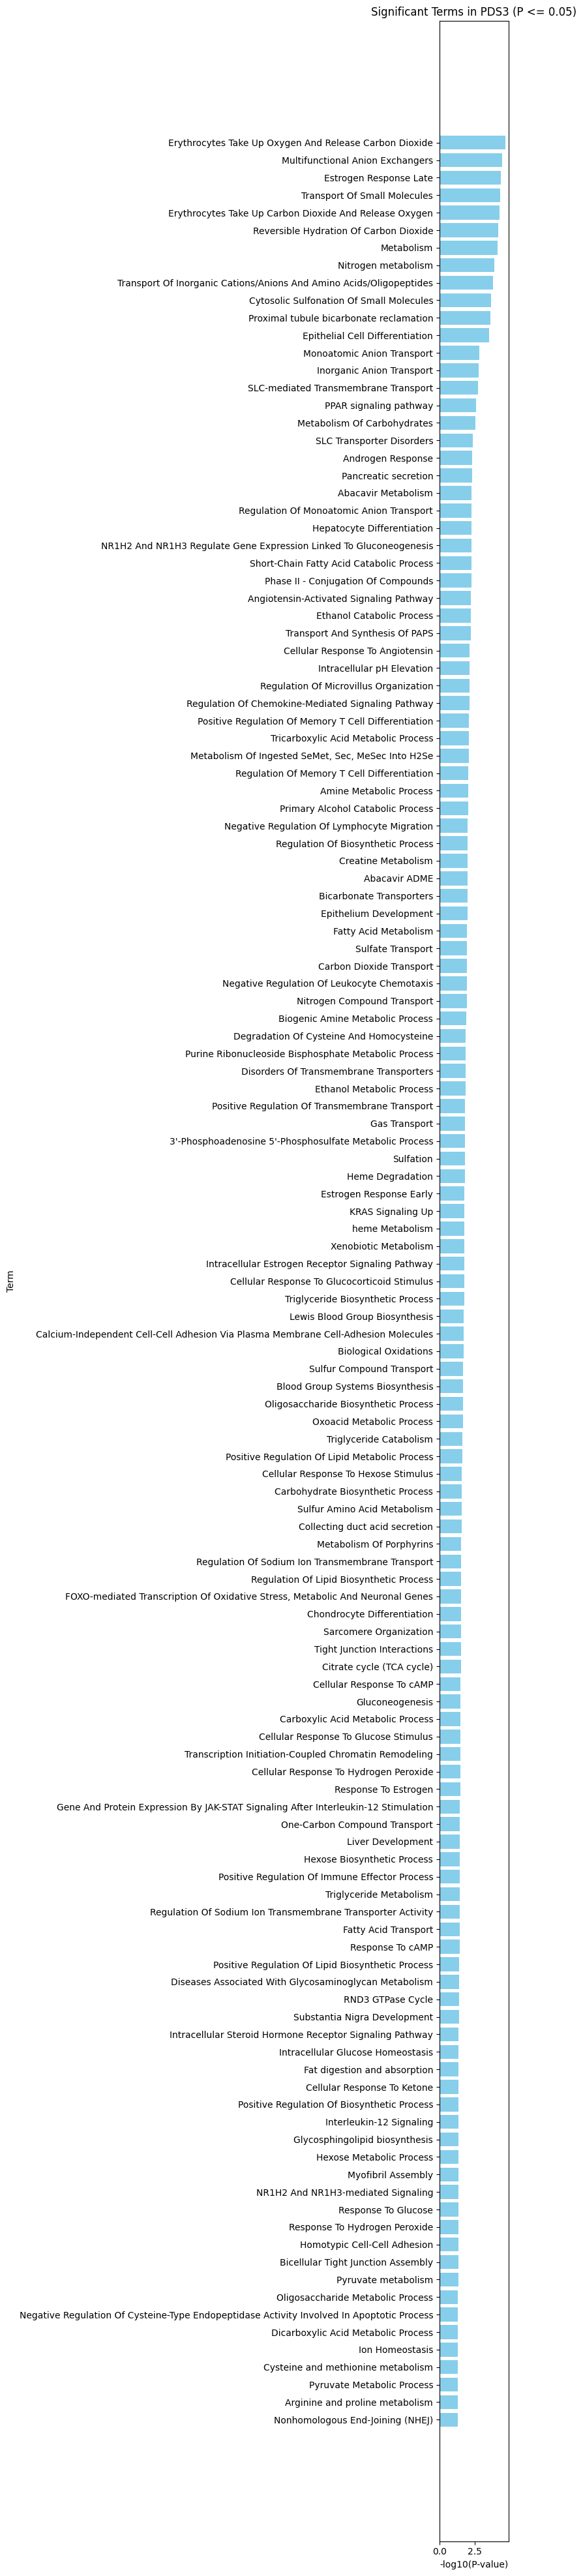

In [172]:
adata_PDS = adata_merged[
    adata_merged.obs['UnsupervisedL1'].isin(['Intestinal Epithelial']) &
    adata_merged.obs['PDS'].isin(['PDS1', 'PDS2', 'PDS3'])
].copy()

sc.tl.rank_genes_groups(adata_PDS, 'PDS', method="wilcoxon",use_raw =False)
sc.pl.rank_genes_groups(adata_PDS, n_genes=50, sharey=False)
sc.tl.dendrogram(adata_PDS, groupby='PDS')
sc.pl.rank_genes_groups_dotplot(
        adata_PDS, groupby="PDS", standard_scale="var",  n_genes=5, use_raw=False
)
import pandas as pd
import scanpy as sc

# 2. 결과 저장
result = adata_PDS.uns["rank_genes_groups"]
groups = result["names"].dtype.names  # 예: ("Tcells", "Bcells", ...)

# 3. DataFrame 변환
result_df = pd.DataFrame(
    {
        f"{group}_{key}": result[key][group]
        for group in groups
        for key in ["names", "pvals_adj", "logfoldchanges", "scores"]
    }
)

# 4. 결과 저장 딕셔너리
up_dict = {}
down_dict = {}

# 5. 자동 반복 처리
for group in groups:
    n_col = f"{group}_names"
    p_col = f"{group}_pvals_adj"
    l_col = f"{group}_logfoldchanges"
    s_col = f"{group}_scores"

    degs_sig = result_df[result_df[p_col] < 0.05]
    degs_up = degs_sig[degs_sig[l_col] > 1].sort_values(by=s_col, ascending=False)
    degs_dw = degs_sig[degs_sig[l_col] < -1].sort_values(by=s_col, ascending=True)

    # 유전자 이름만 추출
    up_dict[group] = degs_up[n_col].reset_index(drop=True)
    down_dict[group] = degs_dw[n_col].reset_index(drop=True)

# 6. 병합
df_merge_up = pd.concat(up_dict.values(), axis=1)
df_merge_up.columns = list(up_dict.keys())  # 각 열 이름을 group 이름으로

df_merge_down = pd.concat(down_dict.values(), axis=1)
df_merge_down.columns = list(down_dict.keys())

sc.tl.dendrogram(adata_PDS, groupby='PDS')
sc.pl.rank_genes_groups_dotplot(
        adata_PDS, groupby="PDS", standard_scale="var",  n_genes=5, use_raw=False
)

import pandas as pd
import scanpy as sc

# 2. 결과 저장
result = adata_PDS.uns["rank_genes_groups"]
groups = result["names"].dtype.names  # 예: ("Tcells", "Bcells", ...)

# 3. DataFrame 변환
result_df = pd.DataFrame(
    {
        f"{group}_{key}": result[key][group]
        for group in groups
        for key in ["names", "pvals_adj", "logfoldchanges", "scores"]
    }
)

# 4. 결과 저장 딕셔너리
up_dict = {}
down_dict = {}

# 5. 자동 반복 처리
for group in groups:
    n_col = f"{group}_names"
    p_col = f"{group}_pvals_adj"
    l_col = f"{group}_logfoldchanges"
    s_col = f"{group}_scores"

    degs_sig = result_df[result_df[p_col] < 0.05]
    degs_up = degs_sig[degs_sig[l_col] > 1].sort_values(by=s_col, ascending=False)
    degs_dw = degs_sig[degs_sig[l_col] < -1].sort_values(by=s_col, ascending=True)

    # 유전자 이름만 추출
    up_dict[group] = degs_up[n_col].reset_index(drop=True)
    down_dict[group] = degs_dw[n_col].reset_index(drop=True)

# 6. 병합
df_merge_up = pd.concat(up_dict.values(), axis=1)
df_merge_up.columns = list(up_dict.keys())  # 각 열 이름을 group 이름으로

df_merge_down = pd.concat(down_dict.values(), axis=1)
df_merge_down.columns = list(down_dict.keys())

from qed.data import readtxt, readseurat, readscanpy
from qed.data import get_enrichment_dataframes
from qed.data import merge_df
from qed.data import query
import inspect
import pandas as pd

# ✅ 사용자 정의 GeneSet 클래스
class GeneSet:
    def __init__(self, genes, name, annot=None):
        self.genes = genes
        self.name = name
        self.params = {}
        self.GO = []
        self.annot = annot or {}

# ✅ enrichment에 사용할 데이터베이스 목록
dblist = [
    'KEGG_2021_Human',
    'Reactome_2022',
    'MSigDB_Hallmark_2020',
    'GO_Biological_Process_2023',
    'WikiPathway_2024_Human'
]

# ✅ DEG 테이블 상위 20개 추출 및 저장
df_merge_up_100 = df_merge_up.head(20)
df_merge_up_100.to_csv('breast_cancer_DEG_up_leiden.csv', index=False, header=True)

# ✅ CSV 불러오기
alist = pd.read_csv('breast_cancer_DEG_up_leiden.csv')

# ✅ 각 열마다 GeneSet 객체로 변환
geneset_list = []
for col in alist.columns:
    genes = alist[col].dropna().tolist()
    gs = GeneSet(genes=genes, name=col, annot={"Leiden": col})
    geneset_list.append(gs)

# ✅ enrichment 실행
aalist = get_enrichment_dataframes(
    geneset_list=geneset_list,
    dblist=dblist,
    annot_colname="Leiden",
    n_jobs=None,
    handle_error=True,
    max_iter=1
)

# ✅ 결과 병합 및 후처리
df = merge_df(aalist)
df['Term'] = df['Term'].str.split(r'\(GO:').str[0].str.strip()
df['Term'] = df['Term'].str.split('R-H').str[0].str.strip()
df['Term'] = df['Term'].str.split('WP').str[0].str.strip()

from typing import List, Tuple, Dict
def heatmap_with_groupwise_ordering(df: pd.DataFrame,
                                     n: int,
                                     group_by: str,
                                     order_by: str = "Adjusted p-value",
                                     cmap: str = 'Blues',
                                     xlabel_rotation: int = 90,
                                     xlabel_fontsize: int = 15,
                                     ylabel_fontsize: int = 15,
                                     figsize: Tuple = (15, 10),
                                     vmin: float = None,
                                     vmax: float = None,
                                     cbar_kws: Dict = None,
                                     linewidths: float = 0.1,
                                     title: str = None,
                                     save_to_file: str = None,
                                     enable_column_order: bool = False,
                                     column_order: list = None,
                                     enable_highlight_columns: bool = False,
                                     highlight_column_names: list = None):

    if not isinstance(df, pd.DataFrame):
        raise TypeError("입력 'df'는 pandas DataFrame이어야 합니다.")
    if group_by not in df.columns:
        raise ValueError(f"'{group_by}' 컬럼이 DataFrame에 존재하지 않습니다.")
    if order_by not in df.columns:
        raise ValueError(f"'{order_by}' 컬럼이 DataFrame에 존재하지 않습니다.")
    if 'Term' not in df.columns:
        raise ValueError("'Term' 컬럼이 DataFrame에 존재하지 않습니다.")

    has_overlapping_genes = 'Overlapping genes' in df.columns

    # P-value 컬럼 숫자형 강제 변환
    df_copy = df.copy()
    df_copy[order_by] = pd.to_numeric(df_copy[order_by], errors='coerce')
    df = df_copy

    df['Term_lower'] = df['Term'].str.lower()

    # 상위 n개 Term 추출
    df_filtered_by_order = df[df[order_by].notna()]
    df_ranked_per_group = (
        df_filtered_by_order
        .sort_values(order_by)
        .groupby(group_by)
        .head(n)
        .reset_index(drop=True)
    )
    if df_ranked_per_group.empty:
        print(f"⚠️ 각 그룹에서 상위 {n}개의 Term을 선택할 수 없습니다.")
        return None, None

    all_selected_terms_lower = df_ranked_per_group['Term_lower'].unique()

    # Overlapping genes 처리
    overlapping_genes_pivot = pd.DataFrame()
    if has_overlapping_genes:
        overlapping_genes_df = df[df['Term_lower'].isin(all_selected_terms_lower)][['Term_lower', group_by, 'Overlapping genes']]
        overlapping_genes_df['Overlapping genes'] = overlapping_genes_df['Overlapping genes'].apply(
            lambda x: ', '.join(map(str, x)) if isinstance(x, list) else str(x)
        )
        overlapping_genes_df = overlapping_genes_df.groupby(['Term_lower', group_by])['Overlapping genes'].apply(', '.join).reset_index()
        overlapping_genes_df.rename(columns={'Term_lower': 'Term'}, inplace=True)
        overlapping_genes_pivot = overlapping_genes_df.pivot(index='Term', columns=group_by, values='Overlapping genes').fillna('')
        overlapping_genes_pivot.index = overlapping_genes_pivot.index.map(lambda x: x.capitalize())

    # P-value pivot table
    aggregated_df = df[df['Term_lower'].isin(all_selected_terms_lower)].groupby(['Term_lower', group_by], as_index=False)[order_by].min()
    aggregated_df.rename(columns={'Term_lower': 'Term'}, inplace=True)
    pivot_df = aggregated_df.pivot(index="Term", columns=group_by, values=order_by).fillna(1).rename_axis(None, axis=1)

    # Log 변환
    is_pvalue_column = order_by.lower() in ['adjusted p-value', 'p-value']
    pivot_df_for_heatmap = -np.log10(np.maximum(pivot_df, np.finfo(float).eps)) if is_pvalue_column else pivot_df.copy()
    pivot_df_for_heatmap.index = pivot_df_for_heatmap.index.map(lambda x: x.capitalize())

    # ✅ Overlapping genes와 결합
    final_pivot_df = pd.concat([pivot_df_for_heatmap, overlapping_genes_pivot], axis=1)

    if save_to_file:
        try:
            final_pivot_df.to_csv(save_to_file, encoding='utf-8-sig')
            print(f"✅ 히트맵 데이터 저장 완료: '{save_to_file}'")
        except Exception as e:
            print(f"❌ 저장 실패: {e}")

    # ✅ column_order 기준 row 정렬
    row_order = []
    seen_terms = set()

    if enable_column_order and column_order:
        group_order_for_plot = [group for group in column_order if group in df[group_by].unique()]
    else:
        group_order_for_plot = df[group_by].unique()

    for group in group_order_for_plot:
        current_group_terms = df_ranked_per_group[df_ranked_per_group[group_by] == group].sort_values(order_by)
        for term_lower_val in current_group_terms['Term_lower']:
            capitalized_term = term_lower_val.capitalize()
            if capitalized_term in pivot_df_for_heatmap.index and capitalized_term not in seen_terms:
                row_order.append(capitalized_term)
                seen_terms.add(capitalized_term)

    clustered_data = final_pivot_df.loc[row_order]
    heatmap_data = clustered_data.select_dtypes(include=[np.number])
   # 1️⃣ 사용자 지정 column_order가 있으면 그 순서 적용
    if enable_column_order and column_order:
        valid_cols = [c for c in column_order if c in heatmap_data.columns]
        if valid_cols:
            heatmap_data = heatmap_data[valid_cols]

# 2️⃣ column_order가 없고, 열 이름이 전부 숫자로 해석 가능하면 오름차순 정렬
    else:
        try:
        # 모든 열 이름을 float으로 바꿔 보고 성공하면 오름차순 재정렬
            numeric_col_keys = [float(c) for c in heatmap_data.columns]
            sorted_cols = [col for _, col in sorted(zip(numeric_col_keys, heatmap_data.columns))]
            heatmap_data = heatmap_data[sorted_cols]
        except ValueError:
        # 열 이름이 숫자가 아닌 게 섞여 있으면 그대로 둡니다
            pass


    if is_pvalue_column:
        p_values_for_annotation = 10 ** (-np.clip(heatmap_data, None, 300))
        annotations = np.where(p_values_for_annotation <= 0.05, '*', '')
        annotations = annotations.astype(object)
    else:
        annotations = False

    # ✅ 열 강조 인덱스 계산 (선 추가)
    highlight_column_indices = []
    if enable_highlight_columns and highlight_column_names:
        highlight_column_indices = [
            list(heatmap_data.columns).index(col)
            for col in highlight_column_names if col in heatmap_data.columns
        ]

    # ✅ 시각화
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(heatmap_data, cmap=cmap, vmin=vmin, vmax=vmax,
                linewidths=linewidths, annot=annotations, fmt='',
                linecolor='white', ax=ax, cbar_kws=cbar_kws, square=True,
                annot_kws={"size": 12, "color": "white", "weight": "bold"})

    # 수직선 추가
    for x in highlight_column_indices:
        ax.vlines(x + 1, *ax.get_ylim(), colors='black', linewidth=2)

    plt.xticks(rotation=xlabel_rotation, fontsize=xlabel_fontsize)
    plt.yticks(fontsize=ylabel_fontsize)
    if title:
        ax.set_title(title, fontsize=18, pad=20)
    plt.grid(False)

    if 'Term_lower' in df.columns:
        df.drop(columns='Term_lower', inplace=True)

    return fig, ax

fig, ax = heatmap_with_groupwise_ordering(
    df= df,
    n=5,
    group_by='Leiden',
    order_by="Adjusted p-value",
    cmap='Reds',
    xlabel_rotation=90,
    xlabel_fontsize=13,
    ylabel_fontsize=13,
    figsize=(3, 14),
    vmin=0, vmax=6,
    cbar_kws={'shrink': 0.5, 'label': '-log10(P-value)'},
    enable_column_order=False,
   # column_order=[
   #     "Contractile cardiomyocyte", 
   #     "Myogenerative cardiomyocyte", 
   #     "Inflammatory cardiomyocyte"
   # ],
    enable_highlight_columns=False,
   # highlight_column_names=[
   #     "Contractile cardiomyocyte", 
   #     "Inflammatory cardiomyocyte"
   # ]
)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_significant_terms(df, leiden_value='PDS3', pvalue_thresh=0.05):
    # 필터링
    df_filtered = df[(df['Leiden'] == leiden_value) & (df['P-value'] <= pvalue_thresh)].copy()
    
    if df_filtered.empty:
        print("조건을 만족하는 Term이 없습니다.")
        return
    
    # P-value를 -log10 변환 (옵션)
    df_filtered['neg_log10_p'] = -np.log10(df_filtered['P-value'])
    
    # y축 Term 순서를 P-value 기준으로 정렬
    df_filtered = df_filtered.sort_values('neg_log10_p', ascending=True)
    
    # figure 크기 조절 (Term 개수에 따라)
    plt.figure(figsize=(8, max(4, 0.3*len(df_filtered))))
    
    plt.barh(df_filtered['Term'], df_filtered['neg_log10_p'], color='skyblue')
    plt.xlabel('-log10(P-value)')
    plt.ylabel('Term')
    plt.title(f'Significant Terms in {leiden_value} (P <= {pvalue_thresh})')
    
    plt.tight_layout()
    plt.show()


plot_significant_terms(df)
